In [ ]:
import os
import subprocess
import sys
from pathlib import Path


os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
os.environ.setdefault('BITSANDBYTES_NOWELCOME', '1')


MARKER = Path('/content/.cbt_qwen_env_ready_v4')
OLD_MARKERS = [
    Path('/content/.cbt_qwen_env_ready_v3'),
    Path('/content/.cbt_qwen_env_ready_v2'),
]
for old in OLD_MARKERS:
    old.unlink(missing_ok=True)

def sh(cmd):
    print('>>', ' '.join(cmd))
    subprocess.check_call(cmd)

needs_install = not MARKER.exists()
if not needs_install:
    try:
        import torch
        import transformers
        import peft
        import accelerate
        import bitsandbytes as bnb
        assert transformers.__version__ == '4.48.3', transformers.__version__
        assert bnb.__version__ == '0.45.5', bnb.__version__
        print('Environment marker found and pinned versions look correct.')
    except Exception as exc:
        print('Environment marker exists but validation failed:', repr(exc))
        MARKER.unlink(missing_ok=True)
        needs_install = True

if needs_install:
    print('Installing a stable pinned text-only environment...')
    sh([sys.executable, '-m', 'pip', 'uninstall', '-y', 'bitsandbytes', 'transformers', 'peft', 'accelerate', 'torchvision', 'torchaudio', 'torchtext'])
    sh([sys.executable, '-m', 'pip', 'install', '-q', '--no-cache-dir', 'transformers==4.48.3', 'peft==0.14.0', 'accelerate==1.2.1'])
    # Pin 0.45.5 and avoid pulling CUDA-13 runtime dependencies.
    sh([sys.executable, '-m', 'pip', 'install', '-q', '--no-cache-dir', '--force-reinstall', '--no-deps', 'bitsandbytes==0.45.5'])
    sh([sys.executable, '-m', 'pip', 'install', '-q', 'rouge-score', 'bert-score', 'nltk', 'anthropic', 'openai', 'ipywidgets', 'scipy', 'matplotlib'])
    MARKER.write_text('ready')
    print('\nEnvironment fixed. Runtime will restart now. After it reconnects, run from this cell again.')
    os.kill(os.getpid(), 9)

import torch
import transformers
import peft
import accelerate
import bitsandbytes as bnb
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('torch:', torch.__version__)
print('cuda:', torch.version.cuda)
print('cuda available:', torch.cuda.is_available())
print('gpu:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)
print('transformers:', transformers.__version__)
print('peft:', peft.__version__)
print('accelerate:', accelerate.__version__)
print('bitsandbytes:', bnb.__version__)
print('Environment ready.')


Environment marker found and pinned versions look correct.
torch: 2.11.0+cu128
cuda: 12.8
cuda available: True
gpu: NVIDIA A100-SXM4-40GB
transformers: 4.48.3
peft: 0.14.0
accelerate: 1.2.1
bitsandbytes: 0.45.5
Environment ready.


In [ ]:
from google.colab import drive, userdata, output
import gc
import json
import os
import re
import warnings
from pathlib import Path

# Keep this before heavy CUDA allocations.
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
os.environ.setdefault('BITSANDBYTES_NOWELCOME', '1')

import numpy as np
import torch
import torch.nn.functional as F
from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

warnings.filterwarnings('ignore')
drive.mount('/content/drive')
output.enable_custom_widget_manager()

DRIVE_ROOT = Path('/content/drive/MyDrive')
MODEL_ROOT = DRIVE_ROOT / 'models'
RESULT_ROOT = DRIVE_ROOT / 'cbt_results'

BASE_MODEL_PATH = MODEL_ROOT / 'Qwen2.5-32B-Instruct'
LORA_PATH = MODEL_ROOT / 'cbt-qwen32b-lora'
ROBERTA_PATH = MODEL_ROOT / 'roberta-large'
OFFLOAD_DIR = RESULT_ROOT / 'offload'

TEST_DATA_PATH = RESULT_ROOT / 'test_cases.json'
RESPONSES_PATH = RESULT_ROOT / 'responses_for_judge.json'
TRADITIONAL_METRICS_PATH = RESULT_ROOT / 'traditional_metrics.json'
JUDGE_RESULTS_PATH = RESULT_ROOT / 'judge_results.json'
KL_OUTPUT_DIR = RESULT_ROOT / 'kl_results'

for p in [RESULT_ROOT, KL_OUTPUT_DIR, OFFLOAD_DIR]:
    p.mkdir(parents=True, exist_ok=True)

SYSTEM_PROMPT = (
    'You are a compassionate and skilled CBT (Cognitive Behavioral Therapy) therapist. '
    'You help clients identify, examine, and reframe unhelpful thinking patterns using '
    'evidence-based techniques including Socratic questioning, thought records, the cognitive model, '
    'and problem-solving. You are warm, non-judgmental, and clinically precise. '
    'You never provide diagnoses or replace professional care.'
)

def get_secret(name, default=None):
    value = os.environ.get(name)
    if value:
        return value
    try:
        return userdata.get(name) or default
    except Exception:
        return default

def cleanup_gpu():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
        print(f'Free GPU memory: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB')

def get_bnb_config():
    return BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )

def load_tokenizer():
    # Prefer the tokenizer saved with the LoRA adapter, because your HF LoRA repo
    # contains tokenizer files from the fine-tuning run.
    tokenizer_path = LORA_PATH if (LORA_PATH / 'tokenizer.json').exists() else BASE_MODEL_PATH
    tokenizer = AutoTokenizer.from_pretrained(str(tokenizer_path), trust_remote_code=True)
    if tokenizer.pad_token_id is None:
        tokenizer.pad_token = tokenizer.eos_token
    tokenizer.padding_side = 'left'
    print('Tokenizer loaded from:', tokenizer_path)
    print('Tokenizer length:', len(tokenizer), 'pad_token_id:', tokenizer.pad_token_id, 'eos_token_id:', tokenizer.eos_token_id)
    return tokenizer

def load_base_model():
    cleanup_gpu()
    model = AutoModelForCausalLM.from_pretrained(
        str(BASE_MODEL_PATH),
        quantization_config=get_bnb_config(),
        device_map='auto',
        max_memory={0: '35GiB', 'cpu': '90GiB'},
        offload_folder=str(OFFLOAD_DIR),
        low_cpu_mem_usage=True,
        torch_dtype=torch.float16,
        trust_remote_code=True,
        attn_implementation='eager',
    )
    model.eval()
    return model

def load_finetuned_model():
    base_model = load_base_model()
    model = PeftModel.from_pretrained(base_model, str(LORA_PATH), is_trainable=False)
    model.eval()
    return model

def _input_device(mdl):
    # With device_map='auto', the embedding/input device is the first model device.
    try:
        return mdl.get_input_embeddings().weight.device
    except Exception:
        return next(mdl.parameters()).device

def generate_response(mdl, tok, prompt, max_new_tokens=200, do_sample=False):
    msgs = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': prompt},
    ]
    prompt_text = tok.apply_chat_template(
        msgs,
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tok(prompt_text, return_tensors='pt', add_special_tokens=False)
    device = _input_device(mdl)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    gen_kwargs = dict(
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        pad_token_id=tok.pad_token_id,
        eos_token_id=tok.eos_token_id,
        use_cache=True,
    )
    if do_sample:
        gen_kwargs.update(temperature=0.7, top_p=0.9)

    with torch.no_grad():
        outputs = mdl.generate(**inputs, **gen_kwargs)
    return tok.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

print('Paths ready:')
print('BASE_MODEL_PATH:', BASE_MODEL_PATH)
print('LORA_PATH:', LORA_PATH)
print('ROBERTA_PATH:', ROBERTA_PATH)
print('RESULT_ROOT:', RESULT_ROOT)


Mounted at /content/drive
Paths ready:
BASE_MODEL_PATH: /content/drive/MyDrive/models/Qwen2.5-32B-Instruct
LORA_PATH: /content/drive/MyDrive/models/cbt-qwen32b-lora
ROBERTA_PATH: /content/drive/MyDrive/models/roberta-large
RESULT_ROOT: /content/drive/MyDrive/cbt_results


In [ ]:
base_safetensors = list(BASE_MODEL_PATH.glob('*.safetensors'))
print('Base config:', (BASE_MODEL_PATH / 'config.json').exists())
print('Base index:', (BASE_MODEL_PATH / 'model.safetensors.index.json').exists())
print('Base safetensors:', len(base_safetensors))
print('Base total GB:', sum(f.stat().st_size for f in base_safetensors) / 1024**3)
print('LoRA adapter_config:', (LORA_PATH / 'adapter_config.json').exists())
print('LoRA adapter_model:', (LORA_PATH / 'adapter_model.safetensors').exists())
print('RoBERTa config:', (ROBERTA_PATH / 'config.json').exists())

assert (BASE_MODEL_PATH / 'config.json').exists(), 'Missing base config.json'
assert (BASE_MODEL_PATH / 'model.safetensors.index.json').exists(), 'Missing base model.safetensors.index.json'
assert len(base_safetensors) >= 17, 'Base Qwen safetensors are incomplete'
assert (LORA_PATH / 'adapter_config.json').exists(), 'Missing LoRA adapter_config.json'
assert (LORA_PATH / 'adapter_model.safetensors').exists(), 'Missing LoRA adapter_model.safetensors'
print('All required model files are present.')


Base config: True
Base index: True
Base safetensors: 17
Base total GB: 61.027558386325836
LoRA adapter_config: True
LoRA adapter_model: True
RoBERTa config: True
All required model files are present.


## 4. Test Cases


In [ ]:
test_cases = [
    {"id":1,"category":"anxiety","user_input":"I feel extremely anxious about my upcoming exams. I can't stop thinking about failing.","reference":"That sounds really overwhelming. When you notice that anxiety building, what thoughts tend to come up most strongly for you?"},
    {"id":2,"category":"anxiety","user_input":"My chest gets tight whenever I open my revision notes, and then I panic that I will forget everything.","reference":"That physical alarm can feel frightening. When your chest tightens, what prediction is your mind making about what will happen next?"},
    {"id":3,"category":"anxiety","user_input":"I keep checking the exam timetable because I am scared I will miss something important.","reference":"It makes sense that checking feels reassuring for a moment. How long does the relief usually last before the worry comes back?"},
    {"id":4,"category":"anxiety","user_input":"Even when I study, I feel anxious that I am not studying the right things.","reference":"That sounds like uncertainty is keeping the anxiety active. What would be a reasonable enough study plan rather than a perfect one?"},
    {"id":5,"category":"anxiety","user_input":"I wake up already worried about everything I need to do for university.","reference":"Starting the day with worry can be exhausting. If we separated today's tasks from future fears, what is one concrete thing that needs attention first?"},
    {"id":6,"category":"negative_self_talk","user_input":"I keep telling myself I'm not smart enough to succeed in this program.","reference":"That is a painful thought to carry. What evidence do you have that supports that belief, and is there any evidence that might challenge it?"},
    {"id":7,"category":"negative_self_talk","user_input":"Whenever I struggle with a reading, I call myself stupid.","reference":"That inner criticism sounds harsh. If a classmate struggled with the same reading, would you describe them the same way?"},
    {"id":8,"category":"negative_self_talk","user_input":"I got feedback on my essay and now I keep thinking I am useless at writing.","reference":"Feedback can easily turn into a global self-judgment. What specifically did the feedback say, and what did your mind add on top of it?"},
    {"id":9,"category":"negative_self_talk","user_input":"I tell myself I should have known better every time I make a small mistake.","reference":"The word should can carry a lot of pressure. What would be a more accurate and fair way to describe making that mistake?"},
    {"id":10,"category":"negative_self_talk","user_input":"My first thought is always that I am behind everyone else and not good enough.","reference":"That comparison sounds painful and automatic. When that thought appears, how strongly do you believe it from 0 to 100?"},
    {"id":11,"category":"perfectionism","user_input":"If I don't get the highest grade, I feel like I've completely failed.","reference":"It sounds like your sense of success is very all-or-nothing right now. What would it mean about you if you got a good grade but not the highest?"},
    {"id":12,"category":"perfectionism","user_input":"I spend hours rewriting one paragraph because it never feels perfect enough.","reference":"That standard sounds exhausting. How do you decide when work is good enough to submit, rather than endlessly improvable?"},
    {"id":13,"category":"perfectionism","user_input":"I avoid submitting assignments early because I keep finding tiny things to fix.","reference":"It sounds like the possibility of imperfection keeps pulling you back in. What is the cost of continuing to revise past the useful point?"},
    {"id":14,"category":"perfectionism","user_input":"If my presentation is not flawless, I feel embarrassed even before I give it.","reference":"Your mind seems to be setting a very narrow definition of acceptable. What would a realistic, human presentation look like?"},
    {"id":15,"category":"perfectionism","user_input":"I feel I have to understand everything immediately or I am failing.","reference":"That is a demanding rule to live under. What would learning look like if confusion were treated as part of the process?"},
    {"id":16,"category":"catastrophizing","user_input":"I made a mistake in my assignment. My professor must think I am incompetent.","reference":"That sounds like a painful conclusion to jump to. What are some other explanations for why your professor might respond to a mistake?"},
    {"id":17,"category":"catastrophizing","user_input":"If I do badly on this quiz, my whole future is ruined.","reference":"That thought jumps from one quiz to your whole future very quickly. What are the steps between those two points, and how likely is each one?"},
    {"id":18,"category":"catastrophizing","user_input":"I missed one lecture and now I feel like I will never catch up.","reference":"Missing one lecture can feel bigger when anxiety is high. What would catching up look like in the smallest manageable step?"},
    {"id":19,"category":"catastrophizing","user_input":"My supervisor asked to meet, so I am sure something terrible is wrong.","reference":"Your mind is predicting the worst. What are three neutral or practical reasons they might want to meet?"},
    {"id":20,"category":"catastrophizing","user_input":"If I forget one point in my presentation, everyone will think it was a disaster.","reference":"That sounds like the mistake is being magnified. What would the audience realistically notice, and what might they forget quickly?"},
    {"id":21,"category":"avoidance","user_input":"I've been avoiding starting my dissertation because I'm scared it won't be good enough.","reference":"Avoidance can feel protective in the moment. What do you imagine happening if you started, even with something very small today?"},
    {"id":22,"category":"avoidance","user_input":"I keep cleaning my room instead of opening the assignment brief.","reference":"It sounds like cleaning may be helping you escape an uncomfortable feeling. What feeling shows up when you think about opening the brief?"},
    {"id":23,"category":"avoidance","user_input":"I have not emailed my tutor because I am embarrassed that I am behind.","reference":"Reaching out can feel vulnerable. What would you hope your tutor understands if you sent a brief, honest message?"},
    {"id":24,"category":"avoidance","user_input":"I avoid group meetings because I worry I have not done enough work.","reference":"Avoidance may reduce anxiety short term but can make the problem heavier. What is one low-pressure way to re-engage with the group?"},
    {"id":25,"category":"avoidance","user_input":"I put off checking my grades because I am scared of what I will see.","reference":"Waiting can keep the fear active. What support or grounding would help you check the result in a steadier way?"},
    {"id":26,"category":"comparison","user_input":"Everyone in my class seems so confident and capable. I feel like I don't belong here.","reference":"That comparison sounds exhausting. How much do you think you actually know about what is going on inside your classmates?"},
    {"id":27,"category":"comparison","user_input":"My friends finish assignments faster than me, so I think I must be less capable.","reference":"Speed is one visible measure, but it may not tell the whole story. What other signs of capability might you be overlooking in yourself?"},
    {"id":28,"category":"comparison","user_input":"People on LinkedIn already have internships and I feel like I am failing.","reference":"Seeing selected successes online can create a harsh comparison. What information is missing from those posts that might make the comparison less fair?"},
    {"id":29,"category":"comparison","user_input":"When others speak confidently in seminars, I feel smaller and stop contributing.","reference":"That reaction sounds discouraging. What would it be like to treat confidence as a skill people practice rather than proof they belong more than you?"},
    {"id":30,"category":"comparison","user_input":"I compare my draft to published papers and feel ridiculous for even trying.","reference":"That is comparing a work in progress to a finished product. What would be a fairer comparison for where your draft is right now?"},
    {"id":31,"category":"rumination","user_input":"I cannot stop replaying a presentation I gave last week where I stumbled over my words.","reference":"It sounds like your mind keeps returning to that moment. What do you think it is trying to protect you from by doing that?"},
    {"id":32,"category":"rumination","user_input":"I keep thinking about one awkward thing I said in a seminar.","reference":"That replay sounds sticky. When you revisit it, are you learning something new, or does it mostly increase distress?"},
    {"id":33,"category":"rumination","user_input":"At night I go over every mistake I made during the day.","reference":"That sounds draining. Could we separate useful reflection from rumination by asking what one lesson, if any, is worth carrying forward?"},
    {"id":34,"category":"rumination","user_input":"I keep rereading my submitted essay in my mind and finding things I should have changed.","reference":"Once work is submitted, the mind can still act as if it can fix it. What would help you mark this as done for now?"},
    {"id":35,"category":"rumination","user_input":"I replay conversations with my supervisor and wonder if I sounded incompetent.","reference":"It sounds like your mind is searching for certainty about how you came across. What evidence do you have that they saw you that way?"},
    {"id":36,"category":"hopelessness","user_input":"No matter how hard I try, I never seem to improve. What's the point?","reference":"That sense of futility sounds really draining. When you say you never improve, how are you measuring that - what counts as improvement to you?"},
    {"id":37,"category":"hopelessness","user_input":"I feel like I will always be anxious and nothing will change.","reference":"Feeling stuck can make the future look fixed. Have there been moments, even brief ones, when the anxiety was a little less intense?"},
    {"id":38,"category":"hopelessness","user_input":"I have tried planning before and I still fall behind, so I do not see why I should try again.","reference":"It makes sense to feel discouraged after plans have not worked. What was unrealistic about the old plans that we could adjust this time?"},
    {"id":39,"category":"hopelessness","user_input":"Everyone says it gets better, but I do not believe it will for me.","reference":"That disbelief sounds heavy. Rather than forcing optimism, what would be a small sign that things were becoming one percent more manageable?"},
    {"id":40,"category":"hopelessness","user_input":"I failed once before, so I feel like there is no point applying again.","reference":"Past disappointment can make trying again feel risky. What did that experience teach you that could make this attempt different?"},
    {"id":41,"category":"sleep_stress","user_input":"I can't sleep because my mind races with worries about deadlines and whether I'm doing enough.","reference":"Racing thoughts at night can make everything feel more intense. What tends to be the loudest worry when you lie down?"},
    {"id":42,"category":"sleep_stress","user_input":"I lie awake calculating how many hours of sleep I have left, and that makes me more stressed.","reference":"That clock-checking can become part of the anxiety cycle. What happens if you gently shift from calculating sleep to resting your body?"},
    {"id":43,"category":"sleep_stress","user_input":"I stay up late to study, then I am too tired to focus the next day.","reference":"That sounds like a cycle where short-term pressure costs you energy later. What bedtime boundary might protect tomorrow's concentration?"},
    {"id":44,"category":"sleep_stress","user_input":"When I try to sleep, I remember everything I did not finish.","reference":"Unfinished tasks can get louder at night. Would it help to write a brief next-day list earlier so your mind does not have to hold it all?"},
    {"id":45,"category":"sleep_stress","user_input":"I feel guilty going to bed if I have not completed every task.","reference":"That guilt sounds tied to a rule about deserving rest. What evidence says rest is part of effective studying rather than a reward after perfection?"},
    {"id":46,"category":"social_anxiety","user_input":"I'm afraid to ask questions in class because I think others will judge me for not understanding.","reference":"That fear of judgment sounds like it is really holding you back. What do you imagine others are actually thinking when someone asks a question?"},
    {"id":47,"category":"social_anxiety","user_input":"I rehearse what to say in seminars but then stay silent because I worry it will sound silly.","reference":"That sounds like your mind is demanding certainty before you speak. What would be a small, lower-risk contribution you could try?"},
    {"id":48,"category":"social_anxiety","user_input":"I avoid office hours because I feel embarrassed asking for help.","reference":"Asking for help can feel exposing. What would you think of another student who used office hours to understand something better?"},
    {"id":49,"category":"social_anxiety","user_input":"After group discussions, I worry people found me awkward.","reference":"That worry sounds like mind reading after the fact. What observable evidence do you have, and what might be interpretation?"},
    {"id":50,"category":"social_anxiety","user_input":"I get nervous introducing myself to classmates, so I keep to myself.","reference":"Avoiding introductions may protect you from anxiety but also keeps you isolated. What is one simple sentence you could practice using?"},
    {"id":51,"category":"guilt","user_input":"I feel guilty for taking breaks. I feel like I should always be studying.","reference":"That guilt sounds like it might be running on a rule - something like 'I should always be working.' Where do you think that rule came from?"},
    {"id":52,"category":"guilt","user_input":"When I spend time with friends, I feel like I am wasting time I should use for coursework.","reference":"That guilt seems to frame rest and connection as wrong. What role might connection play in keeping you well enough to study?"},
    {"id":53,"category":"guilt","user_input":"I feel bad asking for an extension even though I am overwhelmed.","reference":"It sounds like asking for support feels like failure. What would you say to a friend in the same situation who needed an extension?"},
    {"id":54,"category":"guilt","user_input":"I feel guilty because my parents are paying fees and I am not performing perfectly.","reference":"That is a lot of pressure to hold. How might you separate gratitude and responsibility from the demand to be perfect?"},
    {"id":55,"category":"guilt","user_input":"If I rest, I feel like I am being lazy.","reference":"The word lazy sounds very judging. What facts would distinguish genuine rest from avoidance in this situation?"},
    {"id":56,"category":"identity","user_input":"My whole identity feels tied to my academic performance. If I fail, I don't know who I am.","reference":"When our sense of self becomes so linked to one thing, any threat to it can feel enormous. What other parts of yourself exist outside of your academic role?"},
    {"id":57,"category":"identity","user_input":"If I am not seen as a high achiever, I feel like I have lost my value.","reference":"That sounds like achievement has become tied to worth. What qualities do people value in you that are not grades?"},
    {"id":58,"category":"identity","user_input":"I do not know who I am without being the person who always succeeds.","reference":"That is a powerful and painful belief. What might it be like to define yourself by values and effort, not only outcomes?"},
    {"id":59,"category":"identity","user_input":"A bad mark makes me feel like my entire self is bad.","reference":"That sounds like one result is being used to judge your whole identity. What would a more balanced label for the mark be?"},
    {"id":60,"category":"identity","user_input":"I feel invisible when I am not doing well academically.","reference":"Feeling invisible sounds lonely. Where else in your life do you feel seen, even in small ways?"},
    {"id":61,"category":"control","user_input":"I feel like everything is out of my control and I don't know how to cope.","reference":"That feeling of being out of control can be really frightening. If we looked at this together, what is one small thing that is within your control right now?"},
    {"id":62,"category":"control","user_input":"There are too many deadlines and I feel powerless.","reference":"When everything is grouped together, it can feel impossible. What happens if we list what is fixed, what is flexible, and what you can act on today?"},
    {"id":63,"category":"control","user_input":"I cannot control whether my supervisor likes my work, and that makes me panic.","reference":"Uncertainty about others' reactions is hard. What parts of the work process remain within your influence?"},
    {"id":64,"category":"control","user_input":"My schedule keeps changing and I feel like I cannot manage anything.","reference":"Constant change can make planning feel unstable. What kind of plan would allow for flexibility rather than depend on everything going exactly right?"},
    {"id":65,"category":"control","user_input":"I feel overwhelmed by things I cannot fix, like the job market.","reference":"That is a very understandable worry. Could we separate the larger uncertainty from one preparation step you can take this week?"},
    {"id":66,"category":"mind_reading","user_input":"My supervisor didn't respond to my email quickly. I think they're disappointed in me.","reference":"It sounds like you are reading meaning into the silence. What are some other reasons someone might take time to reply to an email?"},
    {"id":67,"category":"mind_reading","user_input":"My classmates were quiet after my comment, so they probably thought it was stupid.","reference":"Silence can feel loaded when you are anxious. What else could silence in a seminar mean besides negative judgment?"},
    {"id":68,"category":"mind_reading","user_input":"My tutor looked serious, so I think they are unhappy with me.","reference":"You noticed their expression and your mind gave it a meaning. What other explanations might fit that same expression?"},
    {"id":69,"category":"mind_reading","user_input":"Someone left my message on read, and now I think they are annoyed with me.","reference":"That uncertainty can invite mind reading. What evidence would you need before concluding they are annoyed?"},
    {"id":70,"category":"mind_reading","user_input":"I saw two classmates whispering and felt sure they were talking about me.","reference":"That sounds painful and anxiety-provoking. How likely is that interpretation compared with more ordinary possibilities?"},
    {"id":71,"category":"emotional_reasoning","user_input":"I feel like a failure, so I must be one.","reference":"Feelings can be very convincing, but they are not always facts. What would you say to a friend who told you they felt like a failure - would you agree that made it true?"},
    {"id":72,"category":"emotional_reasoning","user_input":"I feel terrified about the assignment, so it must be impossible.","reference":"Fear can make a task look larger than it is. What facts do we have about the assignment, separate from the fear?"},
    {"id":73,"category":"emotional_reasoning","user_input":"I feel guilty, so I assume I have done something wrong.","reference":"Guilt is a signal, but not always proof. What specific action are you judging, and what standard are you using?"},
    {"id":74,"category":"emotional_reasoning","user_input":"I feel behind, so I must actually be failing.","reference":"Feeling behind can be intense. What objective information would help you check whether you are failing or simply under pressure?"},
    {"id":75,"category":"emotional_reasoning","user_input":"I feel embarrassed about asking for help, so asking must be a bad idea.","reference":"Embarrassment can make a helpful action feel unsafe. What are the possible benefits of asking despite that feeling?"},
    {"id":76,"category":"burnout","user_input":"I'm exhausted all the time but I feel too guilty to rest.","reference":"Exhaustion and guilt pulling in opposite directions sounds really draining. What do you think rest would cost you, and what might it give you?"},
    {"id":77,"category":"burnout","user_input":"I used to care about my course, but now I feel numb and detached.","reference":"Feeling numb can be a sign that you have been carrying too much for too long. What has your workload been asking of you lately?"},
    {"id":78,"category":"burnout","user_input":"Even small tasks feel impossible because I am so drained.","reference":"That level of depletion sounds serious. What is the smallest task that would count as a gentle step, not a full recovery plan?"},
    {"id":79,"category":"burnout","user_input":"I am running on caffeine and panic, and I know it is not sustainable.","reference":"You are noticing the cost of the current cycle. What would be one realistic change that protects your energy this week?"},
    {"id":80,"category":"burnout","user_input":"I feel resentful every time I sit down to study because I never get a real break.","reference":"Resentment can be a signal that your needs have been ignored. What kind of break would actually feel restorative rather than just another task?"},
    {"id":81,"category":"future_worry","user_input":"I keep worrying about what will happen after graduation. What if I can't find a job?","reference":"Worrying about the future can pull us away from the present. When that worry shows up, how far into the future are you jumping, and how certain does it feel?"},
    {"id":82,"category":"future_worry","user_input":"I am scared my degree will not be enough and I will fall behind in life.","reference":"That fear sounds big and future-focused. What does 'behind in life' mean to you, and whose timeline are you measuring against?"},
    {"id":83,"category":"future_worry","user_input":"I keep imagining interviews going badly before I have even applied.","reference":"Your mind is rehearsing a feared outcome. What would a more useful rehearsal focus on instead?"},
    {"id":84,"category":"future_worry","user_input":"I worry that one bad semester will close every opportunity.","reference":"That sounds like the future is being narrowed by one semester. What examples show that paths can change after setbacks?"},
    {"id":85,"category":"future_worry","user_input":"I cannot enjoy anything now because I am always thinking about whether my future will work out.","reference":"That worry is stealing from the present. What small present-moment activity could you choose even while the future remains uncertain?"},
    {"id":86,"category":"self_compassion","user_input":"I am so hard on myself. I would never speak to a friend the way I speak to myself.","reference":"That is a really important observation. What do you think gets in the way of extending to yourself the same kindness you would offer a friend?"},
    {"id":87,"category":"self_compassion","user_input":"Part of me thinks being kind to myself will make me lazy.","reference":"That is a common fear. What is the difference between self-compassion and letting yourself avoid responsibility?"},
    {"id":88,"category":"self_compassion","user_input":"When I make a mistake, I punish myself mentally for days.","reference":"That sounds painful and exhausting. What would accountability look like without punishment?"},
    {"id":89,"category":"self_compassion","user_input":"I can comfort other people, but I feel awkward comforting myself.","reference":"Self-kindness can feel unfamiliar at first. What words would you offer someone else in this exact situation?"},
    {"id":90,"category":"self_compassion","user_input":"I feel like I do not deserve kindness until I perform better.","reference":"That belief puts kindness behind a condition. What happens to motivation when kindness is only available after success?"},
    {"id":91,"category":"reassurance_seeking","user_input":"I keep asking my classmates if my work is good enough but it never makes me feel better.","reference":"Reassurance can feel relieving for a moment, but it sounds like the relief does not last. What do you think is driving the need to keep checking?"},
    {"id":92,"category":"reassurance_seeking","user_input":"I send drafts to multiple people because I cannot trust my own judgment.","reference":"It sounds like reassurance is replacing your confidence. What would be one small way to practice making your own assessment first?"},
    {"id":93,"category":"reassurance_seeking","user_input":"After someone says my idea is fine, I still want to ask another person.","reference":"That urge suggests the reassurance is not answering the deeper fear. What are you afraid would happen if you stopped after one opinion?"},
    {"id":94,"category":"reassurance_seeking","user_input":"I keep checking whether my answer is right before submitting anything.","reference":"Checking can reduce anxiety briefly, but it may also keep uncertainty feeling dangerous. How many checks would be reasonable enough?"},
    {"id":95,"category":"reassurance_seeking","user_input":"I ask my friends if they are annoyed with me whenever they seem quiet.","reference":"That sounds like a painful need for certainty in relationships. What other ways could you tolerate the uncertainty before asking again?"},
    {"id":96,"category":"progress","user_input":"I've been trying to think more positively but I still feel anxious. Maybe CBT just doesn't work for me.","reference":"It makes sense to feel discouraged when progress feels slow. What small shifts, even tiny ones, have you noticed since we began working on this together?"},
    {"id":97,"category":"progress","user_input":"I challenged one thought but the anxiety came back, so I feel like I failed.","reference":"A thought coming back does not mean you failed. What did you do differently this time, even if the feeling returned?"},
    {"id":98,"category":"progress","user_input":"I expected CBT to make me feel better quickly, but it is taking longer than I hoped.","reference":"It is understandable to want relief quickly. What would be a realistic sign of progress over weeks rather than minutes?"},
    {"id":99,"category":"progress","user_input":"Some days I use the techniques well, and other days I forget everything.","reference":"That unevenness is very normal when learning a new skill. What helped on the days you were able to use the techniques?"},
    {"id":100,"category":"progress","user_input":"I can see my thoughts more clearly now, but I still do not always believe the balanced thought.","reference":"That is still meaningful progress. How much do you believe the original thought now compared with before you examined it?"},
]

with open(TEST_DATA_PATH, 'w', encoding='utf-8') as f:
    json.dump(test_cases, f, ensure_ascii=False, indent=2)
print(f'Test set ready: {len(test_cases)} cases across {len(set(t["category"] for t in test_cases))} categories')
print('Saved:', TEST_DATA_PATH)


Test set ready: 100 cases across 20 categories
Saved: /content/drive/MyDrive/cbt_results/test_cases.json


In [ ]:
cleanup_gpu()
tokenizer = load_tokenizer()
model = load_finetuned_model()
print('Fine-tuned model loaded!')

smoke = generate_response(model, tokenizer, 'I feel anxious about my exams.', max_new_tokens=80, do_sample=False)
print('\nSmoke test response:')
print(smoke)


Free GPU memory: 39.08 GB
Tokenizer loaded from: /content/drive/MyDrive/models/cbt-qwen32b-lora
Tokenizer length: 151665 pad_token_id: 151643 eos_token_id: 151645
Free GPU memory: 39.08 GB


Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

Fine-tuned model loaded!

Smoke test response:
That sounds really heavy, and I’m glad you said it out loud. Could we slow it down together and name the feeling as specifically as you can right now—like worry, dread, or something else—and then give it a number from 0 to 100 for how strong it feels in this moment?


In [ ]:
import html
import ipywidgets as widgets
from IPython.display import display, HTML

APP_WIDTH = 900
system_prompt = SYSTEM_PROMPT
messages_history = [{'role': 'system', 'content': system_prompt}]

display(HTML('''
<style>
.cbt-chat-app, .cbt-chat-app * {
  box-sizing: border-box;
  font-family: Inter, -apple-system, BlinkMacSystemFont, "Segoe UI", Arial, sans-serif;
}
.cbt-chat-app textarea {
  background: #fffdf9 !important;
  color: #22312a !important;
  border: 1px solid #ddd3c6 !important;
  border-radius: 16px !important;
  padding: 15px 17px !important;
  font-size: 15px !important;
  line-height: 1.45 !important;
  outline: none !important;
  resize: none !important;
  box-shadow: inset 0 1px 2px rgba(38, 48, 42, .04), 0 1px 0 rgba(255,255,255,.7) !important;
}
.cbt-chat-app textarea:focus {
  border-color: #86a996 !important;
  box-shadow: 0 0 0 4px rgba(134,169,150,.18), inset 0 1px 2px rgba(38,48,42,.04) !important;
}
.cbt-chat-app textarea::placeholder {
  color: #8a958e !important;
  opacity: 1 !important;
}
.cbt-chat-app .widget-button button {
  height: 52px !important;
  border: 0 !important;
  border-radius: 16px !important;
  background: #2f4a3d !important;
  color: #fff !important;
  font-size: 15px !important;
  font-weight: 800 !important;
  box-shadow: 0 12px 24px rgba(47,74,61,.22) !important;
  transition: transform .12s ease, background .12s ease, box-shadow .12s ease !important;
}
.cbt-chat-app .widget-button button:hover {
  background: #263d32 !important;
  transform: translateY(-1px);
  box-shadow: 0 16px 28px rgba(47,74,61,.26) !important;
}
.cbt-chat-app .widget-button button:disabled {
  opacity: .65 !important;
  transform: none !important;
}
</style>
'''))

def make_bubble(text, is_user):
    safe_text = html.escape(text).replace('\n', '<br>')
    if is_user:
        return f'''
        <div style="display:flex;justify-content:flex-end;align-items:flex-end;margin:14px 0;">
          <div style="max-width:70%;background:#2f4a3d;color:#fff;padding:13px 16px;border-radius:18px 18px 6px 18px;font-size:15px;line-height:1.6;box-shadow:0 12px 26px rgba(47,74,61,.18);word-break:break-word;">{safe_text}</div>
          <div style="width:34px;height:34px;background:#dcebe1;color:#2f4a3d;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:900;flex-shrink:0;margin-left:10px;">You</div>
        </div>'''
    return f'''
    <div style="display:flex;justify-content:flex-start;align-items:flex-end;margin:14px 0;">
      <div style="width:34px;height:34px;background:#dcebe1;color:#2f4a3d;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:11px;font-weight:900;flex-shrink:0;margin-right:10px;">CBT</div>
      <div style="max-width:70%;background:#fff;color:#22312a;padding:13px 16px;border:1px solid #e4dbd0;border-radius:18px 18px 18px 6px;font-size:15px;line-height:1.6;box-shadow:0 12px 26px rgba(32,43,36,.10);word-break:break-word;">{safe_text}</div>
    </div>'''

initial_msg = make_bubble("Hello, I'm here to support you. What's been on your mind lately?", False)
msgs_html = [initial_msg]

def render_panel(messages_html, status='Ready'):
    status_bg = '#eef7f1' if status == 'Ready' else '#fff3d6' if status == 'Typing' else '#ffe8e0'
    status_fg = '#2f4a3d' if status == 'Ready' else '#745b16' if status == 'Typing' else '#8b2d20'
    return f'''
<div style="width:{APP_WIDTH}px;margin:0 auto;border:1px solid #d8d0c6;border-radius:20px 20px 0 0;overflow:hidden;background:#fbfaf7;box-shadow:0 24px 56px rgba(22,31,26,.22);">
  <div style="height:96px;background:#2f4a3d;padding:0 28px;display:flex;align-items:center;justify-content:space-between;">
    <div style="display:flex;align-items:center;gap:15px;">
      <div style="width:52px;height:52px;background:#dcebe1;color:#2f4a3d;border-radius:50%;display:flex;align-items:center;justify-content:center;font-size:14px;font-weight:900;">CBT</div>
      <div>
        <div style="color:#fff;font-size:24px;font-weight:850;letter-spacing:0;">Fine-tuned Qwen2.5-32B CBT Model</div>
        <div style="color:#bdd8c9;font-size:13px;margin-top:5px;">Powered by Qwen2.5-32B · Fine-tuned model</div>
      </div>
    </div>
    <div style="background:{status_bg};color:{status_fg};border-radius:999px;padding:8px 14px;font-size:13px;font-weight:800;">{status}</div>
  </div>
  <div style="background:linear-gradient(180deg,#fffdf9 0%,#f6f1e9 100%);height:500px;overflow-y:auto;padding:26px 30px;">
    {''.join(messages_html)}
  </div>
</div>
'''

def refresh_chat(status='Ready'):
    chat_output.value = render_panel(msgs_html, status=status)

chat_output = widgets.HTML(value=render_panel(msgs_html))

text_input = widgets.Textarea(
    placeholder="Share what's on your mind...",
    layout=widgets.Layout(width=f'{APP_WIDTH - 164}px', height='66px')
)
send_btn = widgets.Button(
    description='Send',
    layout=widgets.Layout(width='112px', height='52px')
)

composer = widgets.HBox(
    [text_input, send_btn],
    layout=widgets.Layout(
        width=f'{APP_WIDTH}px',
        margin='0 auto',
        padding='14px 18px 16px',
        background='#fbfaf7',
        border='1px solid #d8d0c6',
        border_top='1px solid #e7dfd5',
        border_radius='0 0 20px 20px',
        align_items='center',
        justify_content='space-between'
    )
)

root = widgets.VBox(
    [chat_output, composer],
    layout=widgets.Layout(width=f'{APP_WIDTH}px', margin='0 auto')
)
root.add_class('cbt-chat-app')

def on_send(b):
    user_msg = text_input.value.strip()
    if not user_msg:
        return
    text_input.value = ''
    send_btn.disabled = True
    text_input.disabled = True

    msgs_html.append(make_bubble(user_msg, True))
    thinking = make_bubble('Typing...', False)
    msgs_html.append(thinking)
    refresh_chat(status='Typing')

    try:
        messages_history.append({'role': 'user', 'content': user_msg})
        prompt_text = tokenizer.apply_chat_template(messages_history, tokenize=False, add_generation_prompt=True)
        inputs = tokenizer(prompt_text, return_tensors='pt', add_special_tokens=False)
        device = _input_device(model)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            outputs = model.generate(
                **inputs,
                max_new_tokens=300,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
                use_cache=True,
            )
        response = tokenizer.decode(outputs[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True).strip()
        messages_history.append({'role': 'assistant', 'content': response})
        msgs_html.pop()
        msgs_html.append(make_bubble(response or '(empty response)', False))
        refresh_chat(status='Ready')
    except Exception as exc:
        msgs_html.pop()
        msgs_html.append(make_bubble(f'Generation failed: {type(exc).__name__}: {exc}', False))
        refresh_chat(status='Error')
        raise
    finally:
        send_btn.disabled = False
        text_input.disabled = False

send_btn.on_click(on_send)
display(root)


In [ ]:
print('Generating fine-tuned model responses...')
for i, case in enumerate(test_cases):
    response = generate_response(model, tokenizer, case['user_input'], max_new_tokens=200, do_sample=False)
    case['ft_response'] = response
    case['ft_length'] = len(response.split())
    print(f"[{i + 1}/{len(test_cases)}] {case['category']}: {case['ft_length']} words")

avg_ft_length = int(sum(c['ft_length'] for c in test_cases) / len(test_cases))
print(f'Average FT response length: {avg_ft_length} words')
print(f'Recommended max_new_tokens for base model: {avg_ft_length + 20}')


Generating fine-tuned model responses...
[1/100] anxiety: 50 words
[2/100] anxiety: 51 words
[3/100] anxiety: 50 words
[4/100] anxiety: 55 words
[5/100] anxiety: 32 words
[6/100] negative_self_talk: 49 words
[7/100] negative_self_talk: 44 words
[8/100] negative_self_talk: 59 words
[9/100] negative_self_talk: 56 words
[10/100] negative_self_talk: 47 words
[11/100] perfectionism: 56 words
[12/100] perfectionism: 54 words
[13/100] perfectionism: 52 words
[14/100] perfectionism: 40 words
[15/100] perfectionism: 50 words
[16/100] catastrophizing: 59 words
[17/100] catastrophizing: 44 words
[18/100] catastrophizing: 50 words
[19/100] catastrophizing: 58 words
[20/100] catastrophizing: 38 words
[21/100] avoidance: 54 words
[22/100] avoidance: 66 words
[23/100] avoidance: 57 words
[24/100] avoidance: 54 words
[25/100] avoidance: 67 words
[26/100] comparison: 49 words
[27/100] comparison: 49 words
[28/100] comparison: 50 words
[29/100] comparison: 48 words
[30/100] comparison: 51 words
[31/100]

In [ ]:
del model
cleanup_gpu()
print('Fine-tuned model unloaded. Tokenizer kept for reuse.')


Free GPU memory: 38.94 GB
Fine-tuned model unloaded. Tokenizer kept for reuse.


In [ ]:
base_model = load_base_model()
print('Base model loaded!')

base_max_tokens = avg_ft_length + 20
print(f'Generating base model responses with max_new_tokens={base_max_tokens}...')
for i, case in enumerate(test_cases):
    response = generate_response(base_model, tokenizer, case['user_input'], max_new_tokens=base_max_tokens, do_sample=False)
    case['base_response'] = response
    case['base_length'] = len(response.split())
    print(f"[{i + 1}/{len(test_cases)}] {case['category']}: {case['base_length']} words")

with open(RESPONSES_PATH, 'w', encoding='utf-8') as f:
    json.dump(test_cases, f, ensure_ascii=False, indent=2)
print('Saved responses for judge:', RESPONSES_PATH)


Free GPU memory: 38.94 GB


Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

Base model loaded!
Generating base model responses with max_new_tokens=70...
[1/100] anxiety: 62 words
[2/100] anxiety: 57 words
[3/100] anxiety: 62 words
[4/100] anxiety: 62 words
[5/100] anxiety: 59 words
[6/100] negative_self_talk: 56 words
[7/100] negative_self_talk: 59 words
[8/100] negative_self_talk: 60 words
[9/100] negative_self_talk: 61 words
[10/100] negative_self_talk: 63 words
[11/100] perfectionism: 58 words
[12/100] perfectionism: 62 words
[13/100] perfectionism: 59 words
[14/100] perfectionism: 59 words
[15/100] perfectionism: 57 words
[16/100] catastrophizing: 59 words
[17/100] catastrophizing: 61 words
[18/100] catastrophizing: 61 words
[19/100] catastrophizing: 56 words
[20/100] catastrophizing: 58 words
[21/100] avoidance: 60 words
[22/100] avoidance: 57 words
[23/100] avoidance: 58 words
[24/100] avoidance: 61 words
[25/100] avoidance: 59 words
[26/100] comparison: 56 words
[27/100] comparison: 57 words
[28/100] comparison: 60 words
[29/100] comparison: 61 words
[3

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
import numpy as np
import json

scorer = rouge_scorer.RougeScorer(
    ["rouge1", "rouge2", "rougeL"],
    use_stemmer=True
)
smoothie = SmoothingFunction().method4

results = []

for case in test_cases:
    ref = case["reference"]
    ft_resp = case["ft_response"]
    base_resp = case["base_response"]

    ref_tokens = ref.lower().split()

    ft_bleu = sentence_bleu(
        [ref_tokens],
        ft_resp.lower().split(),
        smoothing_function=smoothie
    )
    base_bleu = sentence_bleu(
        [ref_tokens],
        base_resp.lower().split(),
        smoothing_function=smoothie
    )

    ft_rouge = scorer.score(ref, ft_resp)
    base_rouge = scorer.score(ref, base_resp)

    results.append({
        "id": case["id"],
        "category": case["category"],
        "ft_bleu": ft_bleu,
        "base_bleu": base_bleu,
        "ft_rouge1": ft_rouge["rouge1"].fmeasure,
        "base_rouge1": base_rouge["rouge1"].fmeasure,
        "ft_rouge2": ft_rouge["rouge2"].fmeasure,
        "base_rouge2": base_rouge["rouge2"].fmeasure,
        "ft_rougeL": ft_rouge["rougeL"].fmeasure,
        "base_rougeL": base_rouge["rougeL"].fmeasure,
    })

print("\n" + "=" * 60)
print("TRADITIONAL METRICS SUMMARY")
print("=" * 60)

for metric in ["bleu", "rouge1", "rouge2", "rougeL"]:
    ft_avg = np.mean([r[f"ft_{metric}"] for r in results])
    base_avg = np.mean([r[f"base_{metric}"] for r in results])
    diff = ft_avg - base_avg

    print(
        f"{metric.upper():12} | "
        f"FT: {ft_avg:.4f} | "
        f"Base: {base_avg:.4f} | "
        f"Diff: {diff:+.4f}"
    )

with open(TRADITIONAL_METRICS_PATH, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

print("\nSaved traditional metrics:", TRADITIONAL_METRICS_PATH)


TRADITIONAL METRICS SUMMARY
BLEU         | FT: 0.0161 | Base: 0.0141 | Diff: +0.0020
ROUGE1       | FT: 0.1998 | Base: 0.1999 | Diff: -0.0001
ROUGE2       | FT: 0.0268 | Base: 0.0232 | Diff: +0.0036
ROUGEL       | FT: 0.1375 | Base: 0.1266 | Diff: +0.0109

Saved traditional metrics: /content/drive/MyDrive/cbt_results/traditional_metrics.json


In [ ]:
del base_model
cleanup_gpu()
print('Base model unloaded.')


Free GPU memory: 38.94 GB
Base model unloaded.


In [ ]:
MAX_PROMPT_TOKENS = 256

def build_prompt(tokenizer, user_input):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user', 'content': user_input},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

def get_prompt_logprobs(model, tokenizer, prompt):
    ids = tokenizer(
        prompt,
        return_tensors='pt',
        truncation=True,
        max_length=MAX_PROMPT_TOKENS + 1,
    ).input_ids.to(model.device)
    if ids.shape[1] < 2:
        return None
    with torch.no_grad():
        logits = model(ids).logits
    return F.log_softmax(logits[0, :-1, :].float(), dim=-1).cpu()

def compute_kl_divergence(log_p_ft, log_p_base):
    p_ft = torch.exp(log_p_ft)
    kl = (p_ft * (log_p_ft - log_p_base)).sum(dim=-1)
    return kl.clamp(min=0.0)

def run_kl_inference(cases, model, tokenizer, label):
    logprobs = []
    for i, case in enumerate(cases):
        prompt = build_prompt(tokenizer, case['user_input'])
        lp = get_prompt_logprobs(model, tokenizer, prompt)
        logprobs.append(lp)
        print(f'[{label}] {i + 1}/{len(cases)}')
    return logprobs


In [ ]:
print('[1/4] Loading base model for KL...')
base_model = load_base_model()
print('[2/4] Base model forward passes...')
base_lp = run_kl_inference(test_cases, base_model, tokenizer, 'base')
del base_model
cleanup_gpu()

print('[3/4] Loading fine-tuned model for KL...')
ft_model = load_finetuned_model()
print('[4/4] Fine-tuned model forward passes...')
ft_lp = run_kl_inference(test_cases, ft_model, tokenizer, 'ft')
del ft_model
cleanup_gpu()

kl_results = []
for i, case in enumerate(test_cases):
    lp_ft = ft_lp[i]
    lp_base = base_lp[i]
    if lp_ft is None or lp_base is None:
        continue
    min_t = min(lp_ft.shape[0], lp_base.shape[0])
    kl_t = compute_kl_divergence(lp_ft[:min_t], lp_base[:min_t])
    kl_results.append({
        'id': case['id'],
        'category': case['category'],
        'user_input': case['user_input'],
        'mean_kl': float(kl_t.mean()),
        'max_kl': float(kl_t.max()),
        'num_tokens': int(min_t),
        'kl_per_token': kl_t.tolist(),
    })

mean_kls = [r['mean_kl'] for r in kl_results]
categories = sorted(set(r['category'] for r in kl_results))
cat_stats = {
    c: float(np.mean([r['mean_kl'] for r in kl_results if r['category'] == c]))
    for c in categories
}
kl_summary = {
    'description': 'KL(ft || base) computed at prompt-token positions.',
    'global_mean_kl': float(np.mean(mean_kls)),
    'global_median_kl': float(np.median(mean_kls)),
    'global_std_kl': float(np.std(mean_kls)),
    'per_category': cat_stats,
    'per_sample': kl_results,
    'max_prompt_tokens': MAX_PROMPT_TOKENS,
}

with open(KL_OUTPUT_DIR / 'kl_results.json', 'w', encoding='utf-8') as f:
    json.dump(kl_summary, f, ensure_ascii=False, indent=2)

print('\n' + '=' * 54)
print('KL Divergence Summary')
print('=' * 54)
print(f"Global mean   : {kl_summary['global_mean_kl']:.4f} nats")
print(f"Global median : {kl_summary['global_median_kl']:.4f} nats")
print(f"Std dev       : {kl_summary['global_std_kl']:.4f} nats")
print('Saved KL results:', KL_OUTPUT_DIR / 'kl_results.json')


[1/4] Loading base model for KL...
Free GPU memory: 38.94 GB


Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

[2/4] Base model forward passes...
[base] 1/100
[base] 2/100
[base] 3/100
[base] 4/100
[base] 5/100
[base] 6/100
[base] 7/100
[base] 8/100
[base] 9/100
[base] 10/100
[base] 11/100
[base] 12/100
[base] 13/100
[base] 14/100
[base] 15/100
[base] 16/100
[base] 17/100
[base] 18/100
[base] 19/100
[base] 20/100
[base] 21/100
[base] 22/100
[base] 23/100
[base] 24/100
[base] 25/100
[base] 26/100
[base] 27/100
[base] 28/100
[base] 29/100
[base] 30/100
[base] 31/100
[base] 32/100
[base] 33/100
[base] 34/100
[base] 35/100
[base] 36/100
[base] 37/100
[base] 38/100
[base] 39/100
[base] 40/100
[base] 41/100
[base] 42/100
[base] 43/100
[base] 44/100
[base] 45/100
[base] 46/100
[base] 47/100
[base] 48/100
[base] 49/100
[base] 50/100
[base] 51/100
[base] 52/100
[base] 53/100
[base] 54/100
[base] 55/100
[base] 56/100
[base] 57/100
[base] 58/100
[base] 59/100
[base] 60/100
[base] 61/100
[base] 62/100
[base] 63/100
[base] 64/100
[base] 65/100
[base] 66/100
[base] 67/100
[base] 68/100
[base] 69/100
[base] 7

Loading checkpoint shards:   0%|          | 0/17 [00:00<?, ?it/s]

[4/4] Fine-tuned model forward passes...
[ft] 1/100
[ft] 2/100
[ft] 3/100
[ft] 4/100
[ft] 5/100
[ft] 6/100
[ft] 7/100
[ft] 8/100
[ft] 9/100
[ft] 10/100
[ft] 11/100
[ft] 12/100
[ft] 13/100
[ft] 14/100
[ft] 15/100
[ft] 16/100
[ft] 17/100
[ft] 18/100
[ft] 19/100
[ft] 20/100
[ft] 21/100
[ft] 22/100
[ft] 23/100
[ft] 24/100
[ft] 25/100
[ft] 26/100
[ft] 27/100
[ft] 28/100
[ft] 29/100
[ft] 30/100
[ft] 31/100
[ft] 32/100
[ft] 33/100
[ft] 34/100
[ft] 35/100
[ft] 36/100
[ft] 37/100
[ft] 38/100
[ft] 39/100
[ft] 40/100
[ft] 41/100
[ft] 42/100
[ft] 43/100
[ft] 44/100
[ft] 45/100
[ft] 46/100
[ft] 47/100
[ft] 48/100
[ft] 49/100
[ft] 50/100
[ft] 51/100
[ft] 52/100
[ft] 53/100
[ft] 54/100
[ft] 55/100
[ft] 56/100
[ft] 57/100
[ft] 58/100
[ft] 59/100
[ft] 60/100
[ft] 61/100
[ft] 62/100
[ft] 63/100
[ft] 64/100
[ft] 65/100
[ft] 66/100
[ft] 67/100
[ft] 68/100
[ft] 69/100
[ft] 70/100
[ft] 71/100
[ft] 72/100
[ft] 73/100
[ft] 74/100
[ft] 75/100
[ft] 76/100
[ft] 77/100
[ft] 78/100
[ft] 79/100
[ft] 80/100
[ft] 81/

In [ ]:
import anthropic
import json
import numpy as np
import re
import time

ANTHROPIC_API_KEY = ""
client = anthropic.Anthropic(api_key=ANTHROPIC_API_KEY)

JUDGE_DIMS = [
    "CBT_Accuracy",
    "Empathy",
    "Relevance",
    "Clinical_Appropriateness",
    "Overall",
]

KEY_ALIASES = {
    "CBT_Accuracy": [
        "CBT_Accuracy", "CBT Accuracy", "CBTAccuracy", "cbt_accuracy"
    ],
    "Empathy": [
        "Empathy", "empathy"
    ],
    "Relevance": [
        "Relevance", "relevance"
    ],
    "Clinical_Appropriateness": [
        "Clinical_Appropriateness",
        "Clinical Appropriateness",
        "ClinicalAppropriateness",
        "clinical_appropriateness",
        "clinical appropriateness",
    ],
    "Overall": [
        "Overall", "overall", "Average", "average"
    ],
}

judge_prompt_template = """You are an expert evaluator of CBT (Cognitive Behavioral Therapy) chatbot responses.

Evaluate the following response to a client's message on these 4 dimensions, scoring each from 1-10:

1. CBT_Accuracy: Does the response correctly apply CBT techniques such as Socratic questioning, cognitive restructuring, thought challenging, identifying automatic thoughts, or behavioral activation?
2. Empathy: Is the response warm, non-judgmental, validating, and emotionally attuned?
3. Relevance: Does the response directly address the client's message without going off-topic?
4. Clinical_Appropriateness: Is the response professionally appropriate for a CBT support context, avoiding diagnosis, overclaiming, unsafe advice, or replacing professional care?

Client message:
{user_input}

Response to evaluate:
{response}

Return ONLY valid JSON.
Use EXACTLY these keys:
{{
  "CBT_Accuracy": <number from 1 to 10>,
  "Empathy": <number from 1 to 10>,
  "Relevance": <number from 1 to 10>,
  "Clinical_Appropriateness": <number from 1 to 10>,
  "Overall": <average of the four numeric scores>,
  "Reasoning": "<one concise sentence>"
}}"""

def extract_json(raw):
    raw = raw.strip()
    match = re.search(r"\{.*\}", raw, re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found: {raw[:500]}")
    return json.loads(match.group())

def normalize_judge_dict(d):
    if not isinstance(d, dict):
        d = {}

    normalized = {}

    for target_key, aliases in KEY_ALIASES.items():
        value = None

        for alias in aliases:
            if alias in d:
                value = d[alias]
                break

        if value is None:
            normalized[target_key] = np.nan
        else:
            try:
                normalized[target_key] = float(value)
            except Exception:
                normalized[target_key] = np.nan


    if np.isnan(normalized["Overall"]):
        four_scores = [
            normalized["CBT_Accuracy"],
            normalized["Empathy"],
            normalized["Relevance"],
            normalized["Clinical_Appropriateness"],
        ]
        normalized["Overall"] = float(np.nanmean(four_scores))

    normalized["Reasoning"] = (
        d.get("Reasoning")
        or d.get("reasoning")
        or d.get("Explanation")
        or d.get("explanation")
        or ""
    )

    return normalized

def judge_is_valid(judge_dict):
    judge_dict = normalize_judge_dict(judge_dict)
    for dim in JUDGE_DIMS:
        if dim == "Overall":
            continue
        if np.isnan(judge_dict[dim]):
            return False
    return True

def judge_response(user_input, response, max_retries=3):
    prompt = judge_prompt_template.format(
        user_input=user_input,
        response=response
    )

    last_error = None

    for attempt in range(max_retries):
        try:
            msg = client.messages.create(
                model="claude-sonnet-4-5",
                max_tokens=350,
                temperature=0,
                messages=[
                    {
                        "role": "user",
                        "content": prompt
                    }
                ]
            )

            raw = msg.content[0].text.strip()
            parsed = extract_json(raw)
            normalized = normalize_judge_dict(parsed)


            if not judge_is_valid(normalized):
                raise ValueError(f"Incomplete judge JSON: {normalized}")

            return normalized

        except Exception as e:
            last_error = e
            print(f"Judge failed, retry {attempt + 1}/{max_retries}: {repr(e)}")
            time.sleep(2 + attempt * 2)

    print("Judge failed after retries. Using fallback score.")
    print("Last error:", repr(last_error))

    return {
        "CBT_Accuracy": 5.0,
        "Empathy": 5.0,
        "Relevance": 5.0,
        "Clinical_Appropriateness": 5.0,
        "Overall": 5.0,
        "Reasoning": "judge error fallback"
    }

def save_judge_results():
    with open(JUDGE_RESULTS_PATH, "w", encoding="utf-8") as f:
        json.dump(test_cases, f, ensure_ascii=False, indent=2)

def load_existing_judge_results_if_available():
    global test_cases

    if not JUDGE_RESULTS_PATH.exists():
        return

    try:
        with open(JUDGE_RESULTS_PATH, "r", encoding="utf-8") as f:
            saved_cases = json.load(f)

        saved_by_id = {c["id"]: c for c in saved_cases}

        for case in test_cases:
            saved = saved_by_id.get(case["id"])
            if not saved:
                continue

            if "ft_judge" in saved:
                case["ft_judge"] = saved["ft_judge"]

            if "base_judge" in saved:
                case["base_judge"] = saved["base_judge"]

        print("Loaded existing judge results:", JUDGE_RESULTS_PATH)

    except Exception as e:
        print("Could not load existing judge results:", repr(e))

def needs_judging(case, judge_key):
    if judge_key not in case:
        return True

    normalized = normalize_judge_dict(case[judge_key])
    case[judge_key] = normalized

    return not judge_is_valid(normalized)

def summarize_judge_results():
    print("\n" + "=" * 60)
    print("LLM-AS-JUDGE SUMMARY")
    print("=" * 60)

    for dim in JUDGE_DIMS:
        ft_vals = [c["ft_judge"][dim] for c in test_cases]
        base_vals = [c["base_judge"][dim] for c in test_cases]

        ft_avg = np.nanmean(ft_vals)
        base_avg = np.nanmean(base_vals)
        diff = ft_avg - base_avg

        print(
            f"{dim:28} | "
            f"FT: {ft_avg:.2f} | "
            f"Base: {base_avg:.2f} | "
            f"Diff: {diff:+.2f}"
        )

def find_missing_fields():
    missing = []

    for case in test_cases:
        for judge_key, model_name in [
            ("ft_judge", "ft"),
            ("base_judge", "base"),
        ]:
            if judge_key not in case:
                for dim in JUDGE_DIMS:
                    missing.append((case["id"], model_name, dim))
                continue

            case[judge_key] = normalize_judge_dict(case[judge_key])

            for dim in JUDGE_DIMS:
                if np.isnan(case[judge_key][dim]):
                    missing.append((case["id"], model_name, dim))

    return missing

print("Running LLM-as-Judge evaluation...")

load_existing_judge_results_if_available()

for i, case in enumerate(test_cases):
    print(f"[{i + 1}/{len(test_cases)}] Checking case {case['id']}...")

    if needs_judging(case, "ft_judge"):
        print("  Re-judging fine-tuned response")
        case["ft_judge"] = judge_response(
            case["user_input"],
            case["ft_response"]
        )
        save_judge_results()

    if needs_judging(case, "base_judge"):
        print("  Re-judging base response")
        case["base_judge"] = judge_response(
            case["user_input"],
            case["base_response"]
        )
        save_judge_results()


    case["ft_judge"] = normalize_judge_dict(case["ft_judge"])
    case["base_judge"] = normalize_judge_dict(case["base_judge"])
    save_judge_results()

summarize_judge_results()

missing = find_missing_fields()

if missing:
    print("\nMissing / unparsed judge fields:")
    for item in missing[:50]:
        print(item)
    if len(missing) > 50:
        print(f"... and {len(missing) - 50} more")
else:
    print("\nAll judge fields normalized successfully.")

save_judge_results()
print("\nSaved judge results:", JUDGE_RESULTS_PATH)

Running LLM-as-Judge evaluation...
Loaded existing judge results: /content/drive/MyDrive/cbt_results/judge_results.json
[1/100] Checking case 1...
[2/100] Checking case 2...
[3/100] Checking case 3...
[4/100] Checking case 4...
[5/100] Checking case 5...
[6/100] Checking case 6...
[7/100] Checking case 7...
[8/100] Checking case 8...
[9/100] Checking case 9...
[10/100] Checking case 10...
[11/100] Checking case 11...
[12/100] Checking case 12...
[13/100] Checking case 13...
[14/100] Checking case 14...
[15/100] Checking case 15...
[16/100] Checking case 16...
[17/100] Checking case 17...
[18/100] Checking case 18...
[19/100] Checking case 19...
[20/100] Checking case 20...
  Re-judging base response
[21/100] Checking case 21...
[22/100] Checking case 22...
[23/100] Checking case 23...
[24/100] Checking case 24...
[25/100] Checking case 25...
[26/100] Checking case 26...
[27/100] Checking case 27...
[28/100] Checking case 28...
[29/100] Checking case 29...
[30/100] Checking case 30...
[

Loaded: 100 traditional rows, 1000 judge rows, 100 KL rows


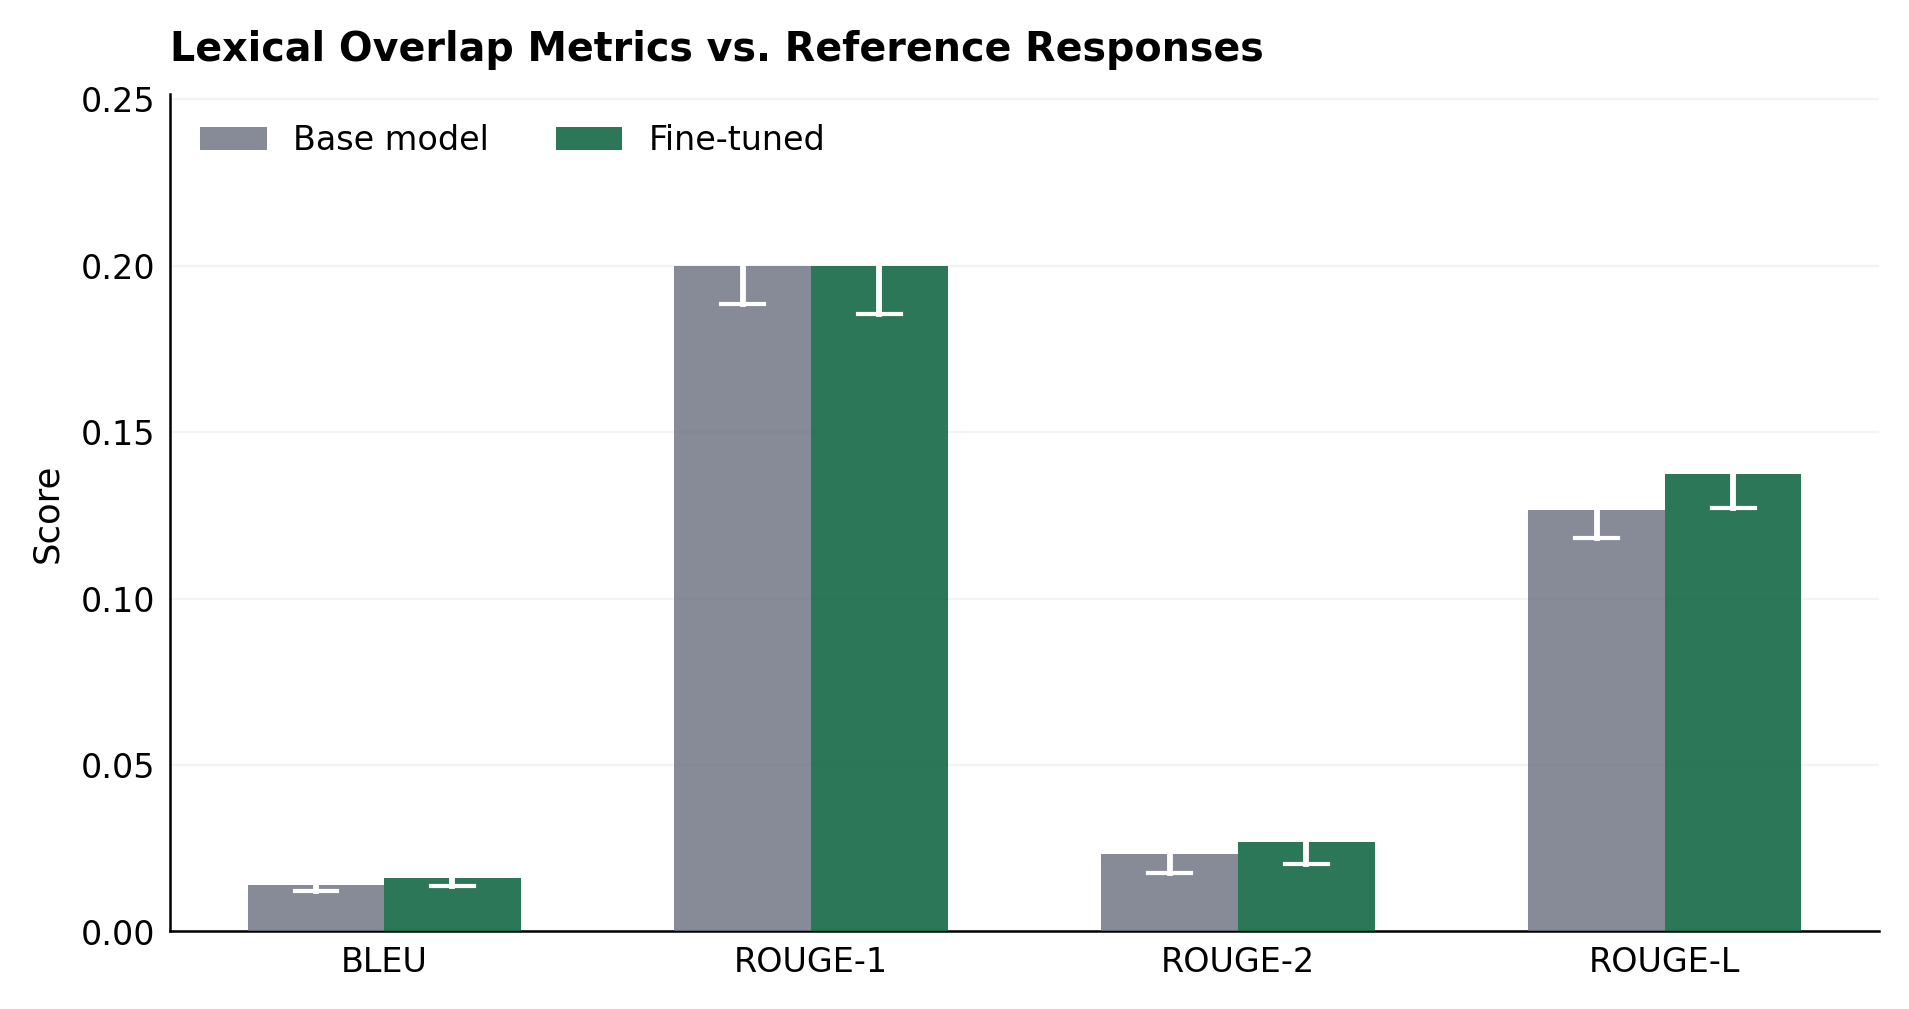

Saved: /content/drive/MyDrive/cbt_results/figures/fig1_traditional_metrics.[pdf/png/svg]


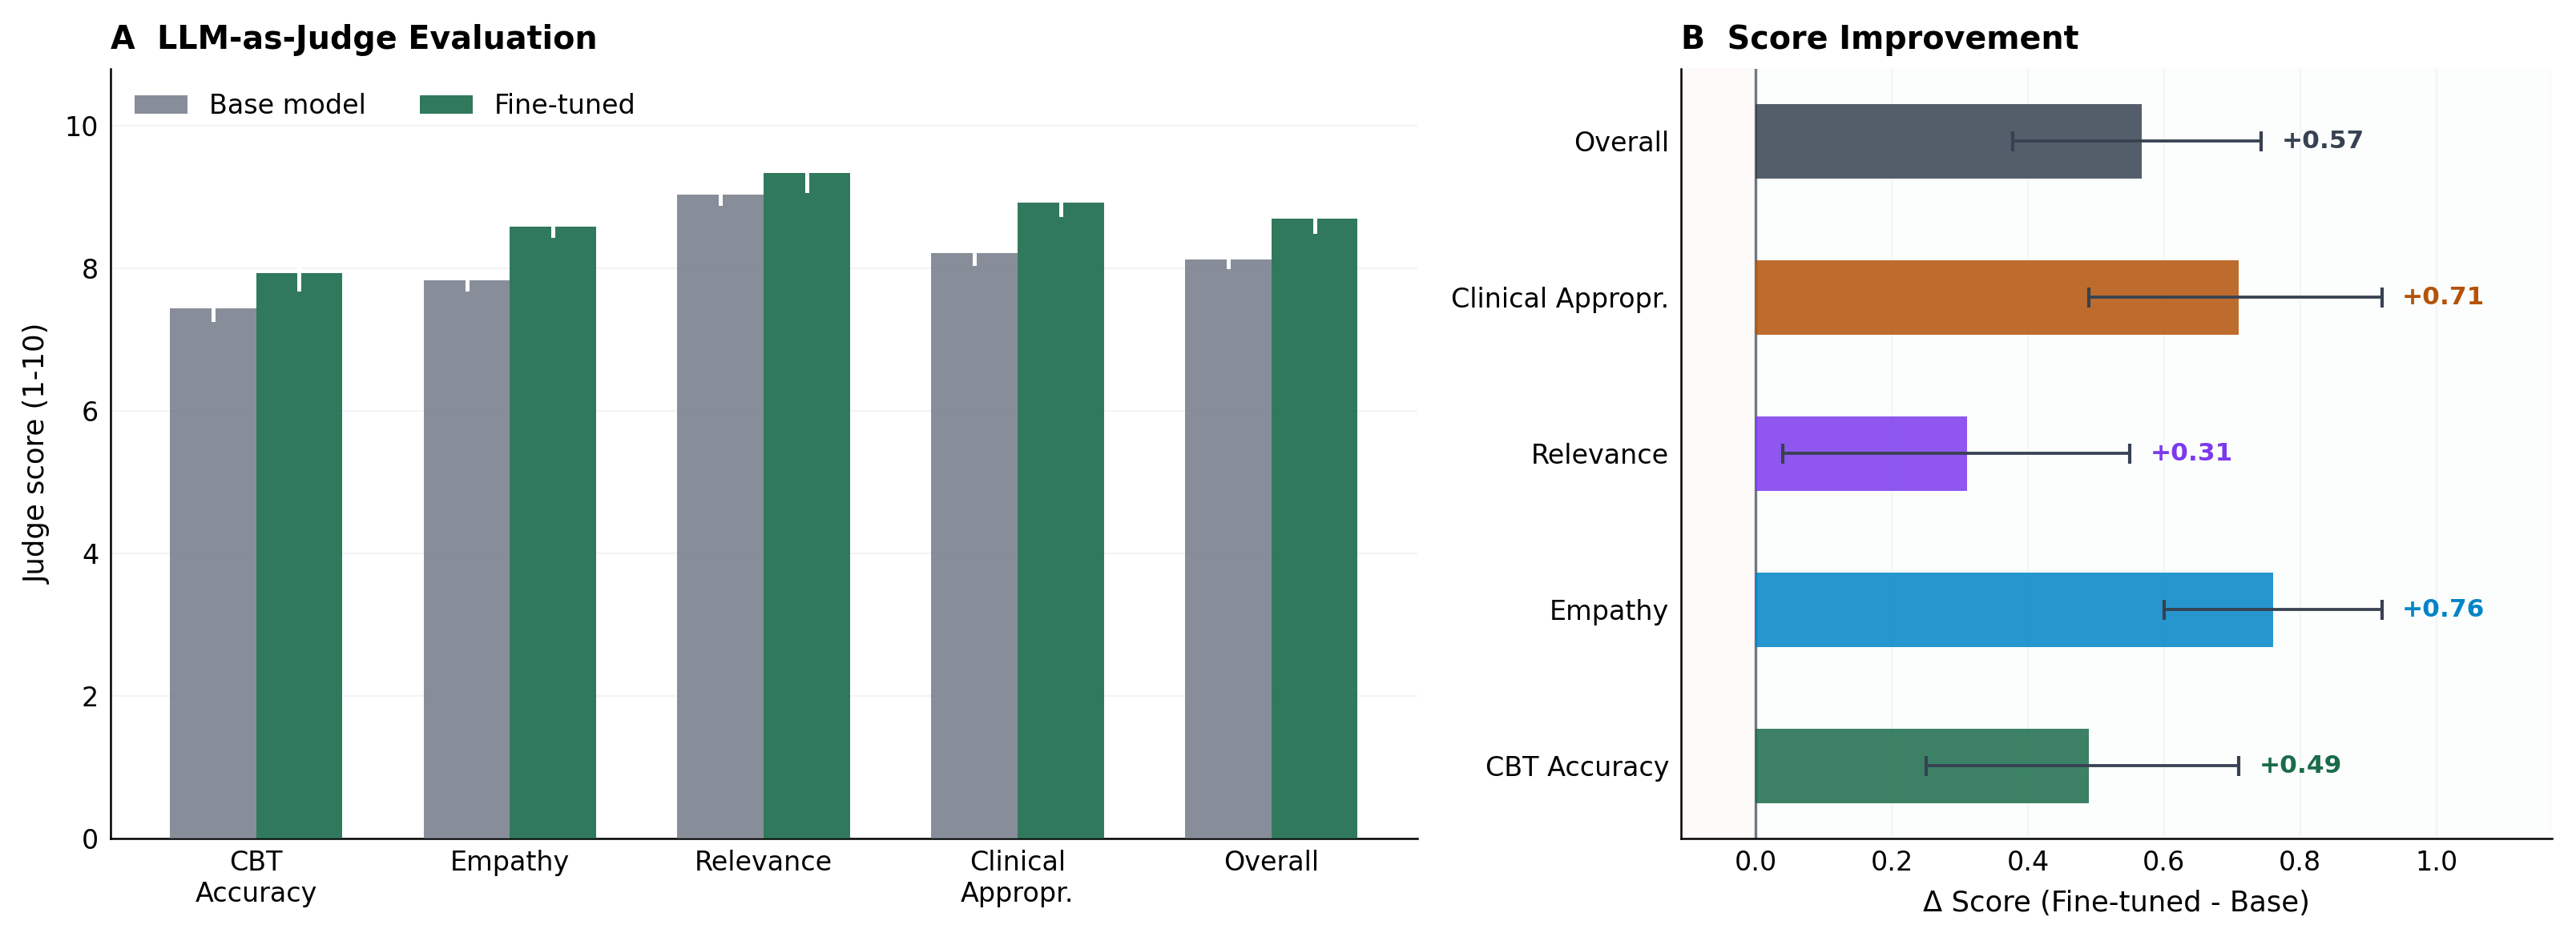

Saved: /content/drive/MyDrive/cbt_results/figures/fig2_llm_judge.[pdf/png/svg]


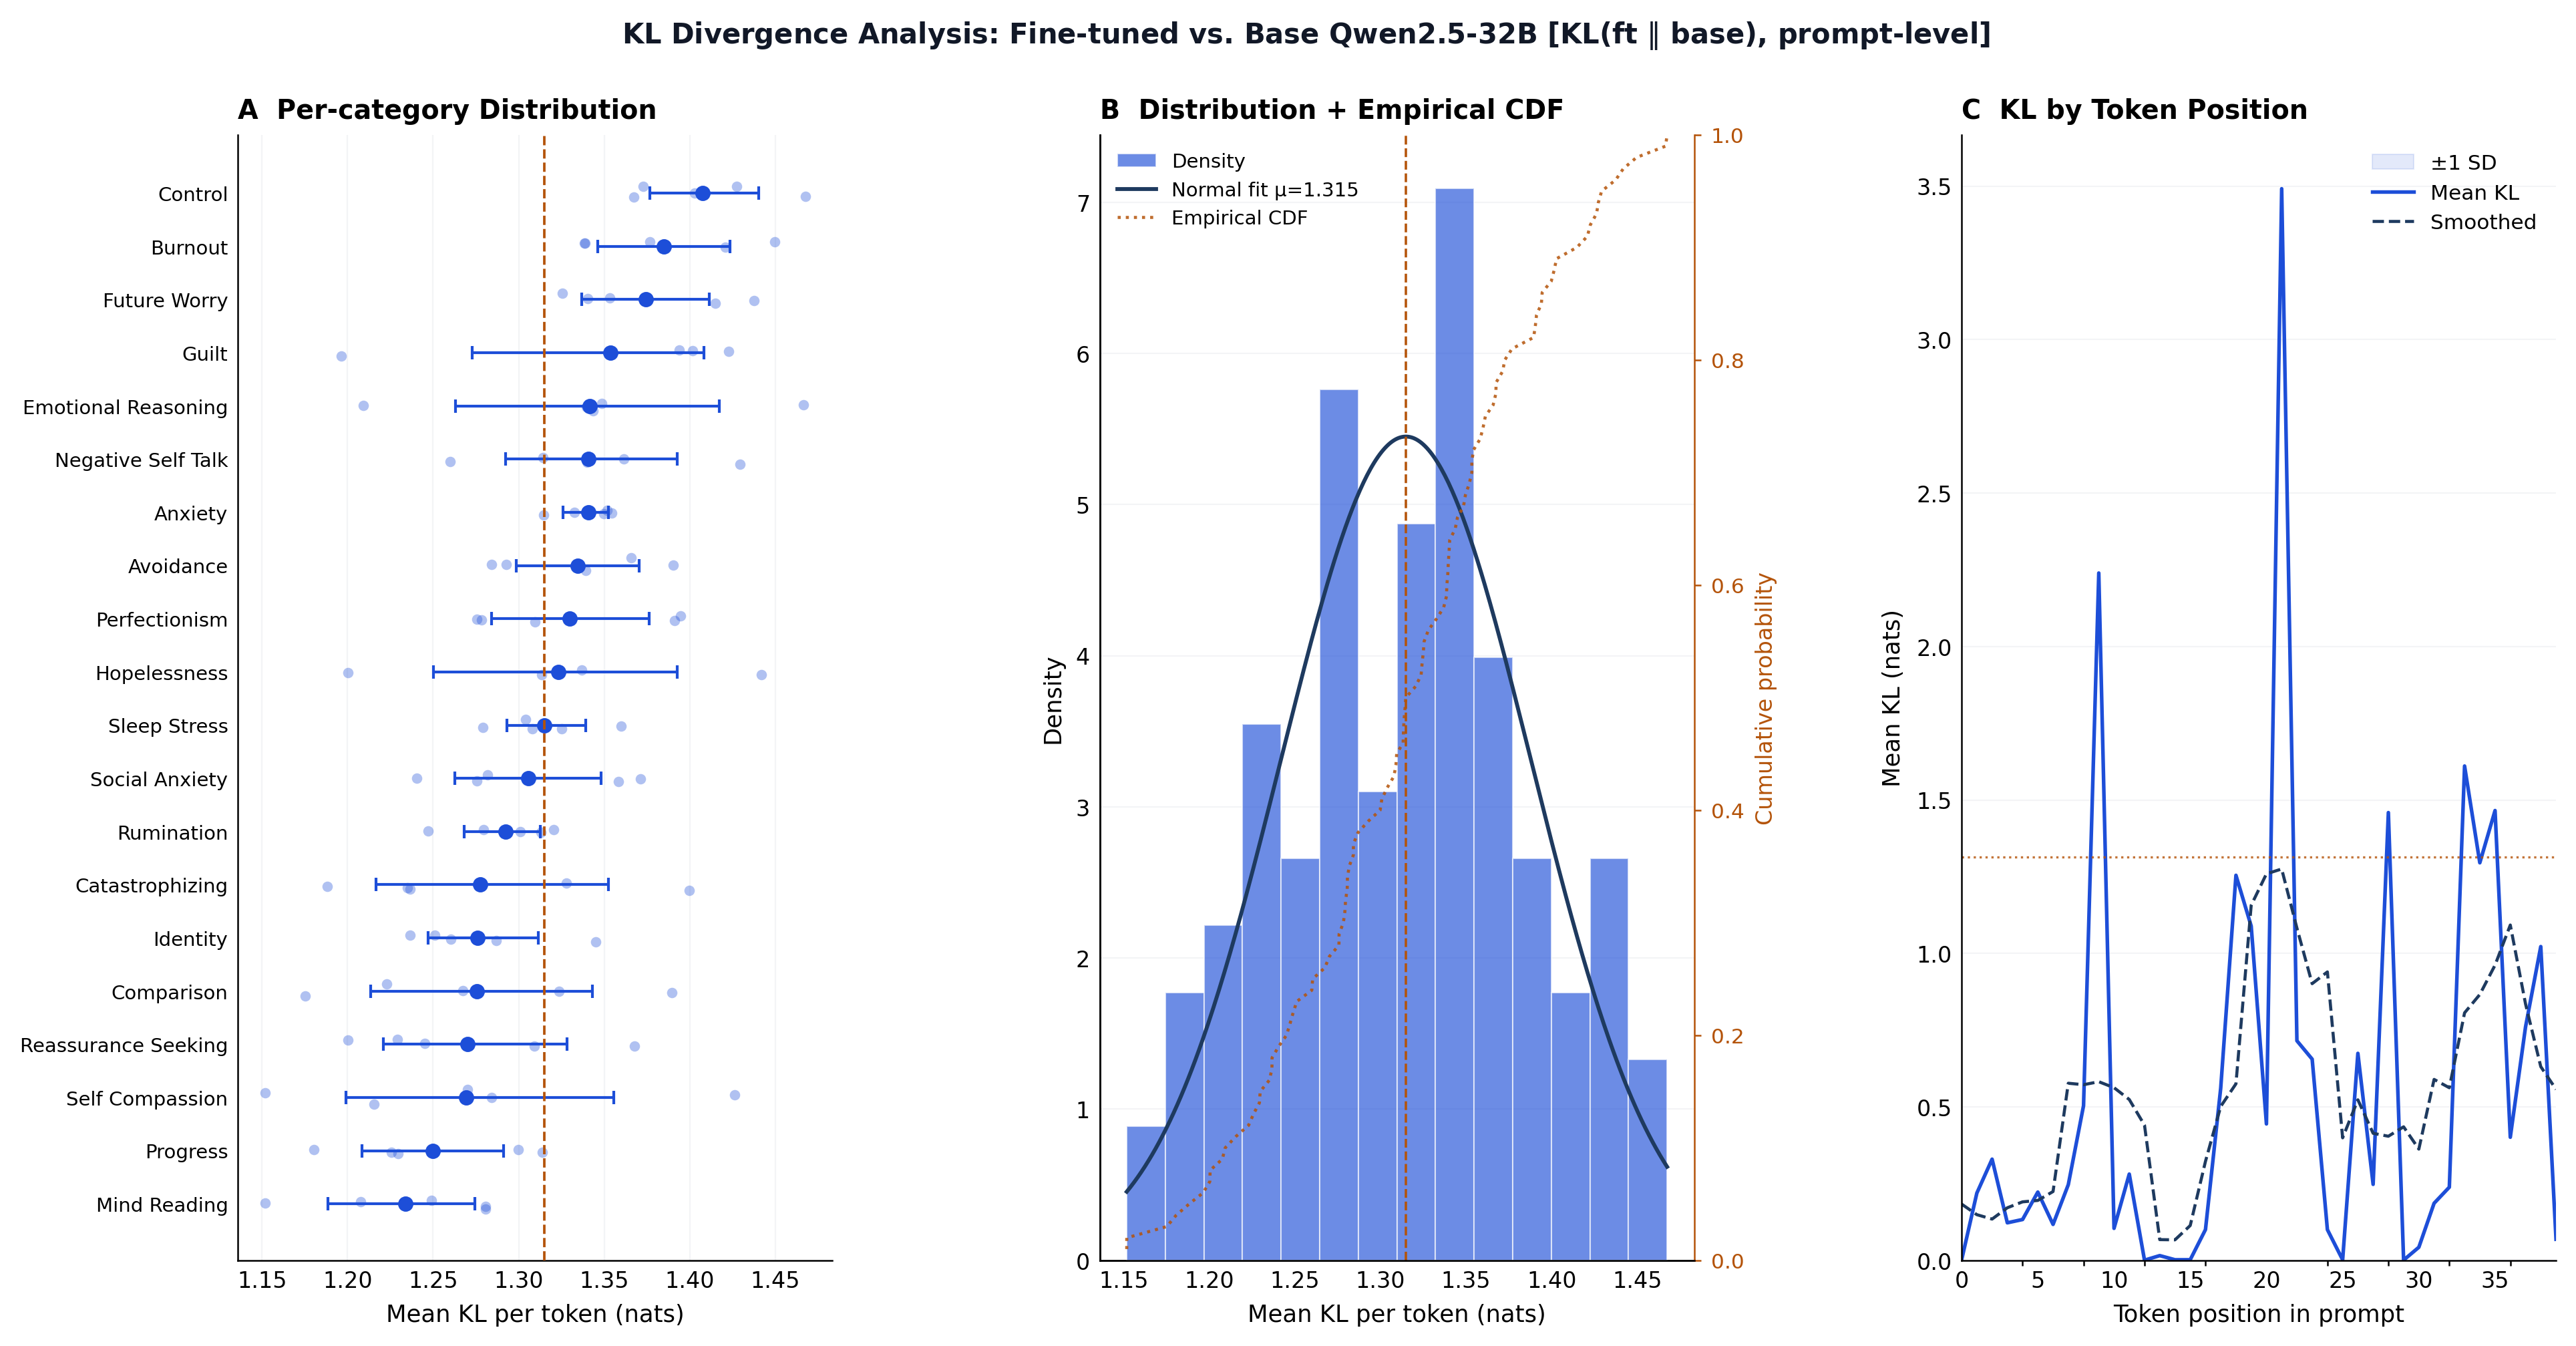

Saved: /content/drive/MyDrive/cbt_results/figures/fig3_kl_analysis.[pdf/png/svg]


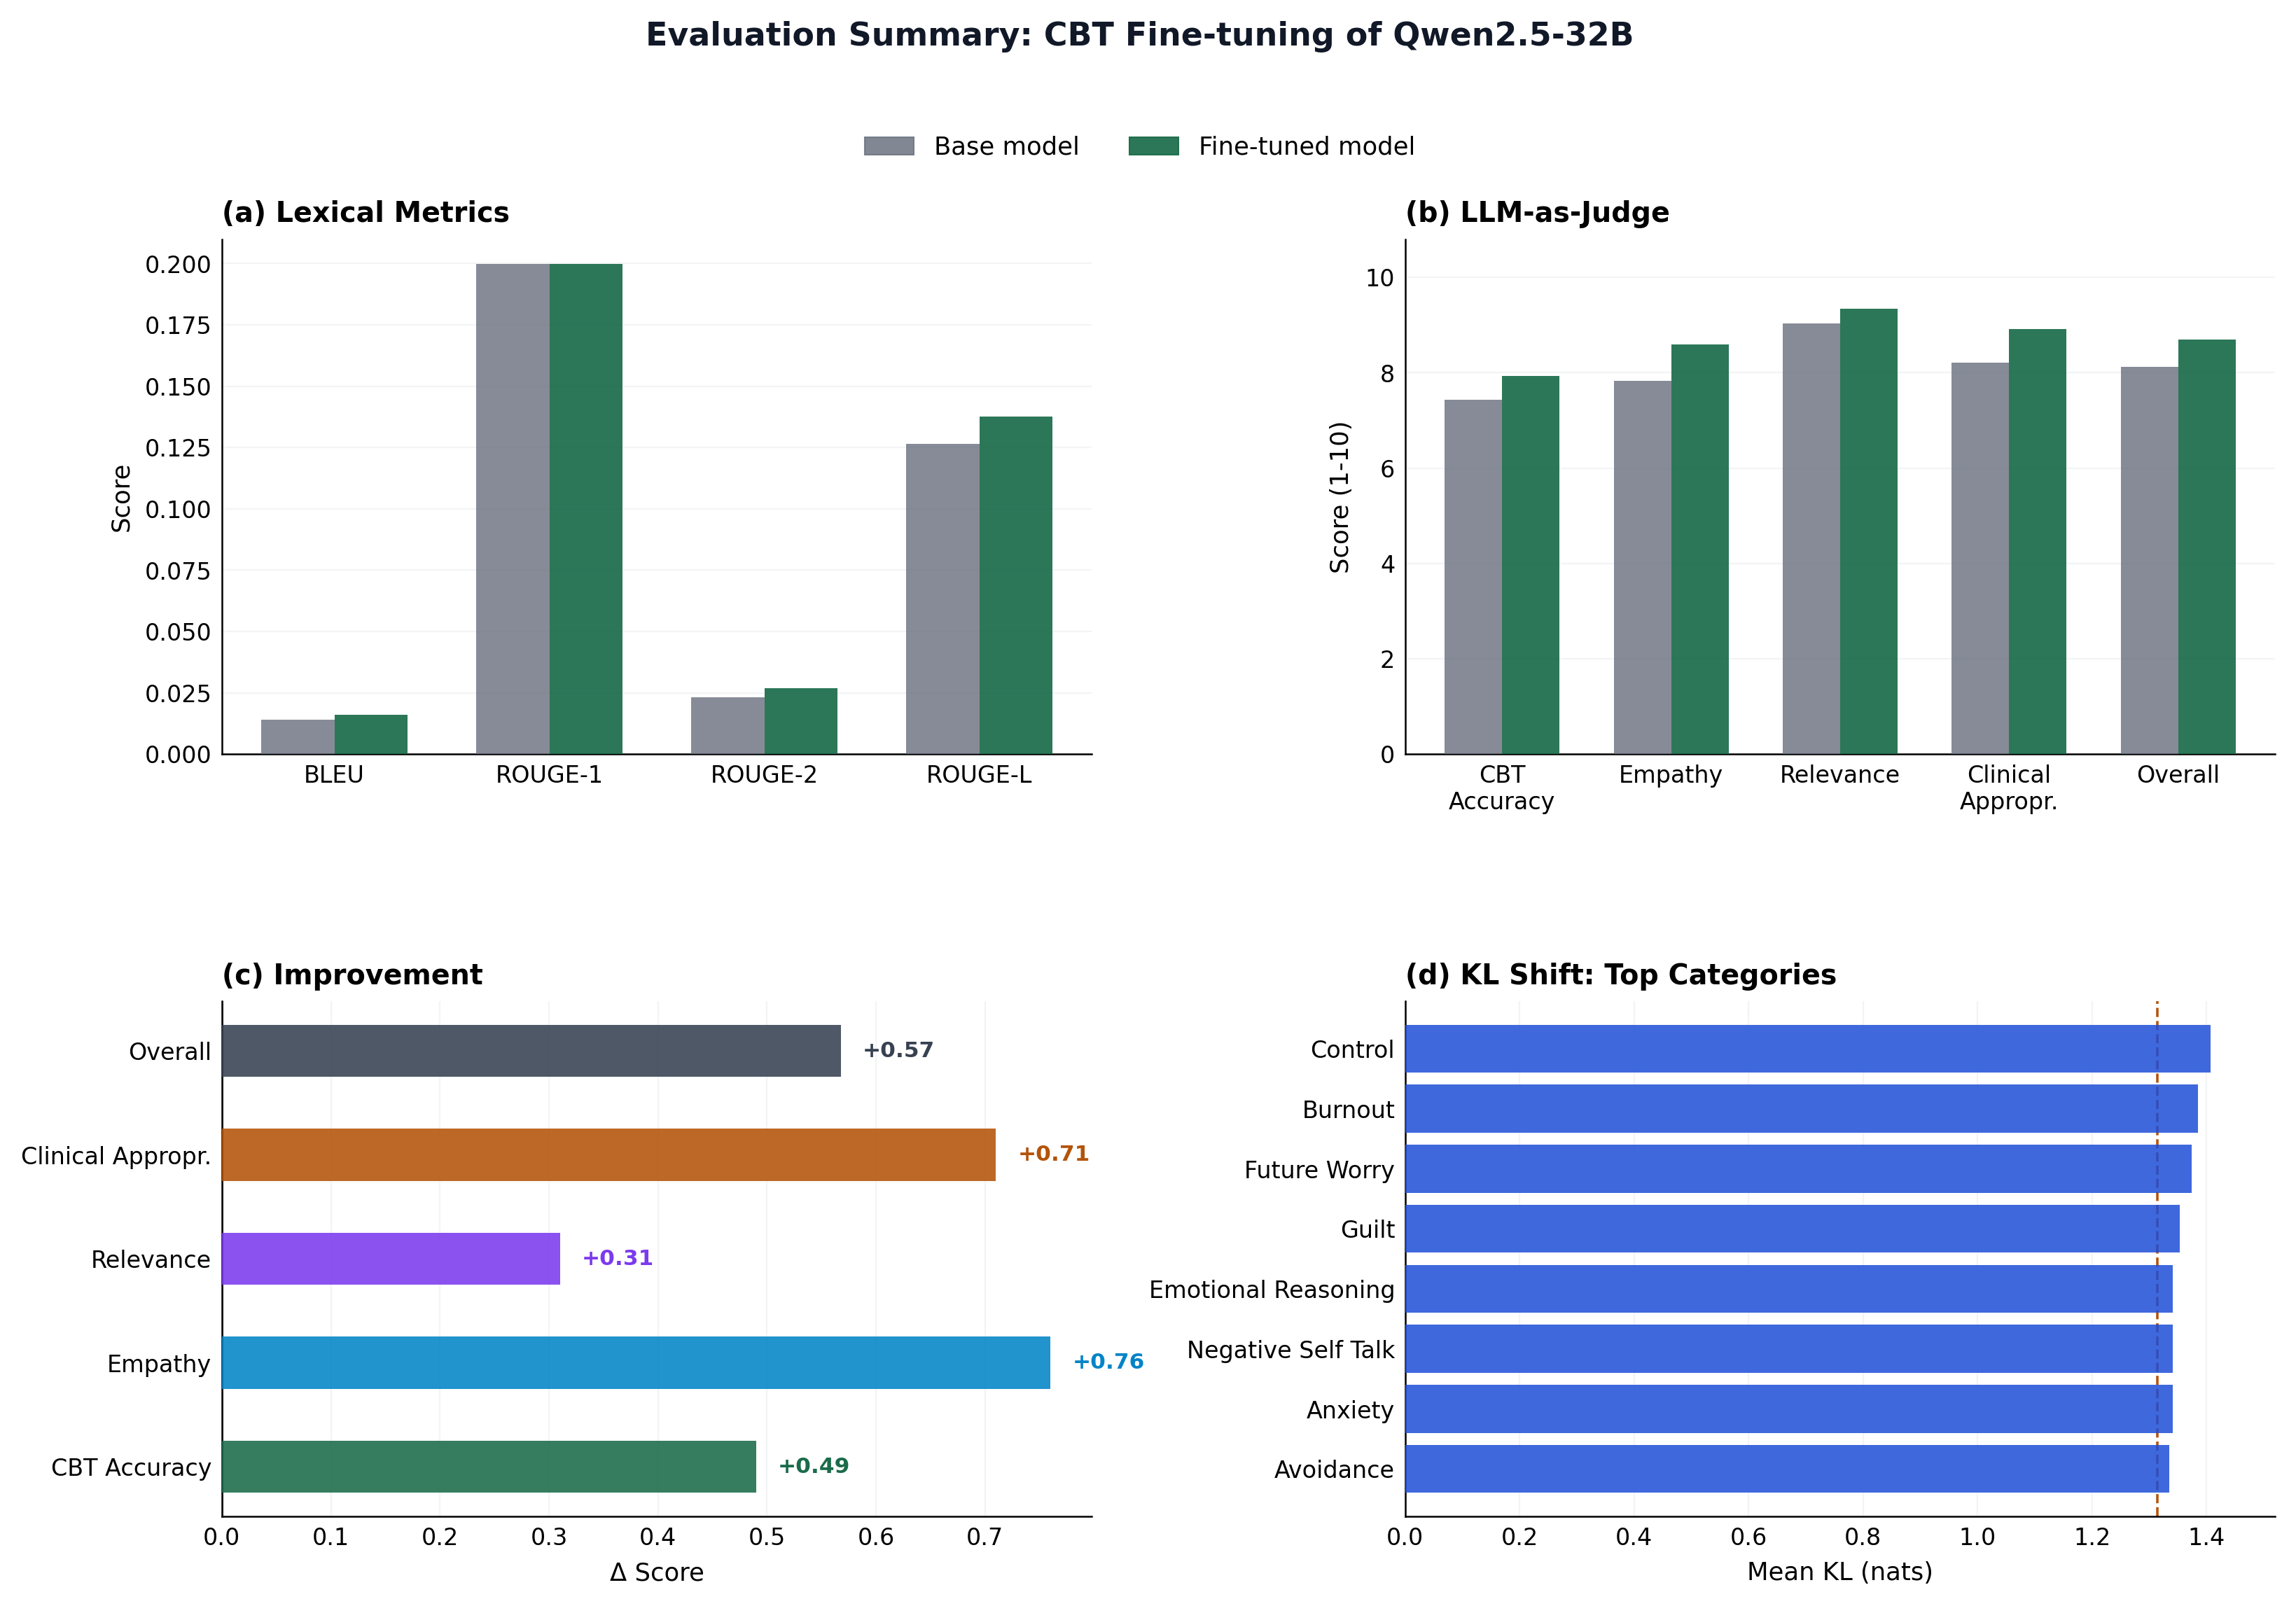

Saved: /content/drive/MyDrive/cbt_results/figures/fig4_main_combined.[pdf/png/svg]

Summary table: /content/drive/MyDrive/cbt_results/figures/summary_table.csv
     family            metric  base_mean  ft_mean      diff
traditional              BLEU   0.014066 0.016083  0.002017
traditional           ROUGE-1   0.199904 0.199766 -0.000138
traditional           ROUGE-2   0.023222 0.026785  0.003563
traditional           ROUGE-L   0.126594 0.137537  0.010943
  llm_judge      CBT Accuracy   7.440000 7.930000  0.490000
  llm_judge           Empathy   7.830000 8.590000  0.760000
  llm_judge         Relevance   9.030000 9.340000  0.310000
  llm_judge Clinical Appropr.   8.210000 8.920000  0.710000
  llm_judge           Overall   8.127500 8.695000  0.567500

All figures saved to: /content/drive/MyDrive/cbt_results/figures


In [ ]:


import json
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
from scipy import stats
from scipy.ndimage import uniform_filter1d
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 8.5,
    "axes.titlesize": 9.5,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "lines.linewidth": 1.1,
    "patch.linewidth": 0.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

C = {
    "base": "#6B7280",
    "ft": "#1A6B4A",
    "diff": "#B45309",
    "kl": "#1D4ED8",
    "grid": "#F3F4F6",
    "zero": "#374151",
}

DIM_COLORS = ["#1A6B4A", "#0284C7", "#7C3AED", "#B45309", "#374151"]

LABELS = {
    "bleu": "BLEU",
    "rouge1": "ROUGE-1",
    "rouge2": "ROUGE-2",
    "rougeL": "ROUGE-L",
    "CBT_Accuracy": "CBT\nAccuracy",
    "Empathy": "Empathy",
    "Relevance": "Relevance",
    "Clinical_Appropriateness": "Clinical\nAppropr.",
    "Overall": "Overall",
}

FIGURE_DIR = RESULT_ROOT / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def mean_ci(values, n_boot=4000, seed=7):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]

    if len(v) == 0:
        return np.nan, np.nan, np.nan

    if len(v) == 1:
        return float(v[0]), float(v[0]), float(v[0])

    rng = np.random.default_rng(seed)
    boots = rng.choice(v, (n_boot, len(v)), replace=True).mean(1)

    return (
        float(v.mean()),
        float(np.percentile(boots, 2.5)),
        float(np.percentile(boots, 97.5)),
    )

def grid(ax):
    ax.yaxis.grid(True, color=C["grid"], linewidth=0.55, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def hgrid(ax):
    ax.xaxis.grid(True, color=C["grid"], linewidth=0.55, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)

def save_figure(fig, stem):
    for ext in ("pdf", "png", "svg"):
        fig.savefig(FIGURE_DIR / f"{stem}.{ext}", bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"Saved: {FIGURE_DIR}/{stem}.[pdf/png/svg]")



trad_raw = json.loads(TRADITIONAL_METRICS_PATH.read_text())
judge_raw = json.loads(JUDGE_RESULTS_PATH.read_text())
kl_raw = json.loads((KL_OUTPUT_DIR / "kl_results.json").read_text())

trad_df = pd.DataFrame(trad_raw)
kl_df = pd.DataFrame(kl_raw.get("per_sample", []))

judge_dims = [
    "CBT_Accuracy",
    "Empathy",
    "Relevance",
    "Clinical_Appropriateness",
    "Overall",
]

judge_rows = []

for case in judge_raw:
    for mk, jk in [("Base", "base_judge"), ("Fine-tuned", "ft_judge")]:
        scores = case.get(jk, {})

        for dim in judge_dims:
            if dim in scores and pd.notna(scores[dim]):
                judge_rows.append({
                    "id": case["id"],
                    "category": case["category"],
                    "model": mk,
                    "dimension": dim,
                    "score": float(scores[dim]),
                })

judge_df = pd.DataFrame(judge_rows)

trad_metrics = [
    m for m in ["bleu", "rouge1", "rouge2", "rougeL"]
    if f"ft_{m}" in trad_df.columns and f"base_{m}" in trad_df.columns
]

gm = kl_raw.get("global_mean_kl", np.nan)
mean_kls = [
    r["mean_kl"]
    for r in kl_raw.get("per_sample", [])
    if "mean_kl" in r
]

print(
    f"Loaded: {len(trad_df)} traditional rows, "
    f"{len(judge_df)} judge rows, {len(kl_df)} KL rows"
)



fig, ax = plt.subplots(figsize=(6.4, 3.4))
fig.patch.set_facecolor("white")

x = np.arange(len(trad_metrics))
w = 0.32

base_stats = [mean_ci(trad_df[f"base_{m}"]) for m in trad_metrics]
ft_stats = [mean_ci(trad_df[f"ft_{m}"]) for m in trad_metrics]

b_means = np.array([s[0] for s in base_stats])
b_lo = np.array([s[1] for s in base_stats])
b_hi = np.array([s[2] for s in base_stats])

f_means = np.array([s[0] for s in ft_stats])
f_lo = np.array([s[1] for s in ft_stats])
f_hi = np.array([s[2] for s in ft_stats])

ax.bar(
    x - w / 2,
    b_means,
    w,
    color=C["base"],
    alpha=0.82,
    label="Base model",
    zorder=3,
    linewidth=0,
)

ax.bar(
    x + w / 2,
    f_means,
    w,
    color=C["ft"],
    alpha=0.92,
    label="Fine-tuned",
    zorder=3,
    linewidth=0,
)

for xi in range(len(trad_metrics)):
    for xpos, lo, hi in [
        (xi - w / 2, b_lo[xi], b_hi[xi]),
        (xi + w / 2, f_lo[xi], f_hi[xi]),
    ]:
        ax.plot([xpos, xpos], [lo, hi], color="white", lw=1.4, zorder=4)
        ax.plot([xpos - 0.05, xpos + 0.05], [lo, lo], color="white", lw=1.0, zorder=4)
        ax.plot([xpos - 0.05, xpos + 0.05], [hi, hi], color="white", lw=1.0, zorder=4)

ymax = max(np.nanmax(b_hi), np.nanmax(f_hi)) * 1.18
ax.set_ylim(0, ymax)

ax.set_xticks(x)
ax.set_xticklabels([LABELS.get(m, m) for m in trad_metrics])
ax.set_ylabel("Score")
ax.set_title(
    "Lexical Overlap Metrics vs. Reference Responses",
    loc="left",
    fontweight="bold",
    pad=8,
)
ax.legend(frameon=False, loc="upper left", ncols=2)
grid(ax)

fig.tight_layout(pad=1.0)
save_figure(fig, "fig1_traditional_metrics")


fig, axes = plt.subplots(
    1,
    2,
    figsize=(10.8, 4.0),
    gridspec_kw={"width_ratios": [1.5, 1]},
)
fig.patch.set_facecolor("white")

ax = axes[0]
x = np.arange(len(judge_dims))
w = 0.34

base_stats = [
    mean_ci(judge_df[(judge_df["model"] == "Base") & (judge_df["dimension"] == d)]["score"])
    for d in judge_dims
]

ft_stats = [
    mean_ci(judge_df[(judge_df["model"] == "Fine-tuned") & (judge_df["dimension"] == d)]["score"])
    for d in judge_dims
]

b_means = np.array([s[0] for s in base_stats])
b_lo = np.array([s[1] for s in base_stats])
b_hi = np.array([s[2] for s in base_stats])

f_means = np.array([s[0] for s in ft_stats])
f_lo = np.array([s[1] for s in ft_stats])
f_hi = np.array([s[2] for s in ft_stats])

ax.bar(
    x - w / 2,
    b_means,
    w,
    color=C["base"],
    alpha=0.80,
    label="Base model",
    zorder=3,
    linewidth=0,
)

ax.bar(
    x + w / 2,
    f_means,
    w,
    color=C["ft"],
    alpha=0.90,
    label="Fine-tuned",
    zorder=3,
    linewidth=0,
)

for xi in range(len(judge_dims)):
    ax.plot([xi - w / 2, xi - w / 2], [b_lo[xi], b_hi[xi]], color="white", lw=1.2, zorder=4)
    ax.plot([xi + w / 2, xi + w / 2], [f_lo[xi], f_hi[xi]], color="white", lw=1.2, zorder=4)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[d] for d in judge_dims])
ax.set_ylabel("Judge score (1-10)")
ax.set_ylim(0, 10.8)
ax.set_title("A  LLM-as-Judge Evaluation", loc="left", fontweight="bold")
ax.legend(frameon=False, loc="upper left", ncols=2)
grid(ax)

ax = axes[1]

diff_data = []

for d in judge_dims:
    bv = judge_df[
        (judge_df["model"] == "Base")
        & (judge_df["dimension"] == d)
    ].sort_values("id")["score"].values

    fv = judge_df[
        (judge_df["model"] == "Fine-tuned")
        & (judge_df["dimension"] == d)
    ].sort_values("id")["score"].values

    n = min(len(bv), len(fv))
    diffs = fv[:n] - bv[:n]
    m, l, h = mean_ci(diffs)

    diff_data.append((d, m, l, h))

y = np.arange(len(diff_data))

means = np.array([d[1] for d in diff_data])
lows = np.array([d[2] for d in diff_data])
highs = np.array([d[3] for d in diff_data])

xmin = min(-0.1, np.nanmin(lows) - 0.15)
xmax = np.nanmax(highs) + 0.25

ax.axvline(0, color=C["zero"], lw=0.8, alpha=0.7, zorder=2)
ax.axvspan(xmin, 0, color="#FEF2F2", alpha=0.35, zorder=1)
ax.axvspan(0, xmax, color="#F0FDF4", alpha=0.25, zorder=1)

for idx, (d, m, l, h) in enumerate(diff_data):
    color = DIM_COLORS[idx]

    ax.barh(
        idx,
        m,
        height=0.48,
        color=color,
        alpha=0.85,
        zorder=3,
        linewidth=0,
    )

    ax.errorbar(
        m,
        idx,
        xerr=[[m - l], [h - m]],
        fmt="none",
        ecolor="#374151",
        capsize=3,
        elinewidth=0.9,
        zorder=4,
    )

    ax.text(
        h + 0.03,
        idx,
        f"{m:+.2f}",
        va="center",
        fontsize=7.5,
        color=color,
        fontweight="bold",
    )

ax.set_xlim(xmin, xmax)
ax.set_yticks(y)
ax.set_yticklabels([LABELS[d[0]].replace("\n", " ") for d in diff_data])
ax.set_xlabel("Δ Score (Fine-tuned - Base)")
ax.set_title("B  Score Improvement", loc="left", fontweight="bold")
hgrid(ax)

fig.tight_layout(pad=1.2)
save_figure(fig, "fig2_llm_judge")



fig = plt.figure(figsize=(13.0, 7.2))

gs = gridspec.GridSpec(
    1,
    3,
    figure=fig,
    wspace=0.45,
    left=0.09,
    right=0.98,
    top=0.90,
    bottom=0.12,
)

fig.patch.set_facecolor("white")
fig.suptitle(
    r"KL Divergence Analysis: Fine-tuned vs. Base Qwen2.5-32B [KL(ft $\|$ base), prompt-level]",
    fontsize=10,
    fontweight="bold",
    y=0.98,
    color="#111827",
)

ax0 = fig.add_subplot(gs[0])

if len(kl_df) > 0:
    cat_order = kl_df.groupby("category")["mean_kl"].mean().sort_values().index.tolist()
    rng = np.random.default_rng(9)

    for yi, cat in enumerate(cat_order):
        vals = kl_df[kl_df["category"] == cat]["mean_kl"].values
        m, l, h = mean_ci(vals)
        jitter = rng.normal(0, 0.06, len(vals))

        ax0.scatter(
            vals,
            np.full(len(vals), yi) + jitter,
            s=14,
            color=C["kl"],
            alpha=0.35,
            linewidths=0,
            zorder=2,
        )

        ax0.errorbar(
            m,
            yi,
            xerr=[[m - l], [h - m]],
            fmt="o",
            ms=4.5,
            color=C["kl"],
            ecolor=C["kl"],
            elinewidth=1.0,
            capsize=2.5,
            zorder=3,
        )

    ax0.axvline(gm, color=C["diff"], lw=0.9, ls="--", zorder=4)
    ax0.set_yticks(range(len(cat_order)))
    ax0.set_yticklabels([c.replace("_", " ").title() for c in cat_order], fontsize=7)

ax0.set_xlabel("Mean KL per token (nats)")
ax0.set_title("A  Per-category Distribution", loc="left", fontweight="bold")
hgrid(ax0)

ax1 = fig.add_subplot(gs[1])
ax1r = ax1.twinx()

if mean_kls:
    ax1.hist(
        mean_kls,
        bins=14,
        color=C["kl"],
        alpha=0.65,
        edgecolor="white",
        lw=0.3,
        density=True,
        zorder=3,
        label="Density",
    )

    mu_f, sd_f = stats.norm.fit(mean_kls)
    xf = np.linspace(min(mean_kls), max(mean_kls), 300)

    ax1.plot(
        xf,
        stats.norm.pdf(xf, mu_f, sd_f),
        color="#1E3A5F",
        lw=1.4,
        label=f"Normal fit μ={mu_f:.3f}",
        zorder=4,
    )

    s_all = np.sort(mean_kls)
    cdf_y = np.arange(1, len(s_all) + 1) / len(s_all)

    ax1r.plot(
        s_all,
        cdf_y,
        color=C["diff"],
        lw=1.1,
        ls=":",
        alpha=0.85,
        label="Empirical CDF",
    )

    ax1.axvline(gm, color=C["diff"], lw=0.85, ls="--", zorder=5)

ax1r.set_ylabel("Cumulative probability", color=C["diff"], fontsize=8)
ax1r.tick_params(axis="y", colors=C["diff"], labelsize=7.5)
ax1r.set_ylim(0, 1)
ax1r.spines["right"].set_visible(True)
ax1r.spines["right"].set_linewidth(0.6)
ax1r.spines["right"].set_color(C["diff"])

ax1.set_xlabel("Mean KL per token (nats)")
ax1.set_ylabel("Density")
ax1.set_title("B  Distribution + Empirical CDF", loc="left", fontweight="bold")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1r.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, frameon=False, fontsize=7, loc="upper left")

ax1.yaxis.grid(True, color=C["grid"], lw=0.5, zorder=0)
ax1.set_axisbelow(True)
ax1.tick_params(length=0)

ax2 = fig.add_subplot(gs[2])
MAX_T = 40

all_seqs = [
    r["kl_per_token"]
    for r in kl_raw.get("per_sample", [])
    if len(r.get("kl_per_token", [])) >= 10
]

if all_seqs:
    padded = np.full((len(all_seqs), MAX_T), np.nan)

    for i, seq in enumerate(all_seqs):
        L = min(len(seq), MAX_T)
        padded[i, :L] = seq[:L]

    mc = np.nanmean(padded, axis=0)
    sc = np.nanstd(padded, axis=0)
    cnt = np.sum(~np.isnan(padded), axis=0)

    vm = cnt > 2
    pos = np.where(vm)[0]

    ax2.fill_between(
        pos,
        (mc - sc)[vm],
        (mc + sc)[vm],
        color=C["kl"],
        alpha=0.12,
        label="±1 SD",
    )

    ax2.plot(
        pos,
        mc[vm],
        color=C["kl"],
        lw=1.3,
        label="Mean KL",
    )

    smooth = uniform_filter1d(mc[vm], size=min(6, len(mc[vm])))

    ax2.plot(
        pos,
        smooth,
        color="#1E3A5F",
        lw=1.1,
        ls="--",
        label="Smoothed",
    )

    ax2.axhline(
        gm,
        color=C["diff"],
        lw=0.8,
        ls=":",
        alpha=0.8,
    )

ax2.set_xlabel("Token position in prompt")
ax2.set_ylabel("Mean KL (nats)")
ax2.set_title("C  KL by Token Position", loc="left", fontweight="bold")
ax2.legend(frameon=False, fontsize=7.5)
ax2.set_xlim(0, MAX_T - 1)
ax2.set_ylim(bottom=0)
ax2.xaxis.set_minor_locator(MultipleLocator(4))
ax2.yaxis.grid(True, color=C["grid"], lw=0.5, zorder=0)
ax2.set_axisbelow(True)
ax2.tick_params(length=0)

save_figure(fig, "fig3_kl_analysis")



fig = plt.figure(figsize=(11.5, 8.0))

gs = gridspec.GridSpec(
    2,
    2,
    figure=fig,
    wspace=0.36,
    hspace=0.48,
    left=0.12,
    right=0.97,
    top=0.84,
    bottom=0.08,
)

fig.patch.set_facecolor("white")

fig.suptitle(
    "Evaluation Summary: CBT Fine-tuning of Qwen2.5-32B",
    fontsize=11,
    fontweight="bold",
    y=0.97,
    color="#111827",
)

ax = fig.add_subplot(gs[0, 0])

x = np.arange(len(trad_metrics))
w = 0.34

bm = [trad_df[f"base_{m}"].mean() for m in trad_metrics]
fm = [trad_df[f"ft_{m}"].mean() for m in trad_metrics]

ax.bar(
    x - w / 2,
    bm,
    w,
    color=C["base"],
    alpha=0.82,
    zorder=3,
    linewidth=0,
)

ax.bar(
    x + w / 2,
    fm,
    w,
    color=C["ft"],
    alpha=0.92,
    zorder=3,
    linewidth=0,
)

ax.set_xticks(x)
ax.set_xticklabels([LABELS.get(m, m) for m in trad_metrics])
ax.set_ylabel("Score")
ax.set_title("(a) Lexical Metrics", loc="left", fontweight="bold", fontsize=9.5)
grid(ax)

ax = fig.add_subplot(gs[0, 1])

x = np.arange(len(judge_dims))
w = 0.34

bm2 = [
    judge_df[
        (judge_df["model"] == "Base")
        & (judge_df["dimension"] == d)
    ]["score"].mean()
    for d in judge_dims
]

fm2 = [
    judge_df[
        (judge_df["model"] == "Fine-tuned")
        & (judge_df["dimension"] == d)
    ]["score"].mean()
    for d in judge_dims
]

ax.bar(
    x - w / 2,
    bm2,
    w,
    color=C["base"],
    alpha=0.82,
    zorder=3,
    linewidth=0,
)

ax.bar(
    x + w / 2,
    fm2,
    w,
    color=C["ft"],
    alpha=0.92,
    zorder=3,
    linewidth=0,
)

ax.set_xticks(x)
ax.set_xticklabels([LABELS[d] for d in judge_dims])
ax.set_ylabel("Score (1-10)")
ax.set_ylim(0, 10.8)
ax.set_title("(b) LLM-as-Judge", loc="left", fontweight="bold", fontsize=9.5)
grid(ax)

ax = fig.add_subplot(gs[1, 0])

ax.axvline(0, color=C["zero"], lw=0.75, alpha=0.7)

for idx, (d, dc) in enumerate(zip(judge_dims, DIM_COLORS)):
    bv = judge_df[
        (judge_df["model"] == "Base")
        & (judge_df["dimension"] == d)
    ].sort_values("id")["score"].values

    fv = judge_df[
        (judge_df["model"] == "Fine-tuned")
        & (judge_df["dimension"] == d)
    ].sort_values("id")["score"].values

    n = min(len(bv), len(fv))
    diff = (fv[:n] - bv[:n]).mean()

    ax.barh(
        idx,
        diff,
        height=0.5,
        color=dc,
        alpha=0.88,
        zorder=3,
        linewidth=0,
    )

    ax.text(
        diff + 0.02,
        idx,
        f"{diff:+.2f}",
        va="center",
        fontsize=7.5,
        color=dc,
        fontweight="bold",
    )

ax.set_yticks(range(len(judge_dims)))
ax.set_yticklabels([LABELS[d].replace("\n", " ") for d in judge_dims], fontsize=8)
ax.set_xlabel("Δ Score")
ax.set_title("(c) Improvement", loc="left", fontweight="bold", fontsize=9.5)
hgrid(ax)

ax = fig.add_subplot(gs[1, 1])

if len(kl_df) > 0:
    top8 = (
        kl_df.groupby("category")["mean_kl"]
        .mean()
        .sort_values(ascending=False)
        .head(8)
    )

    y8 = np.arange(len(top8))

    ax.barh(
        y8,
        top8.values[::-1],
        color=C["kl"],
        alpha=0.85,
        zorder=3,
        linewidth=0,
    )

    ax.axvline(
        gm,
        color=C["diff"],
        lw=0.85,
        ls="--",
    )

    ax.set_xlim(0, float(top8.max()) * 1.08)
    ax.set_yticks(y8)
    ax.set_yticklabels([c.replace("_", " ").title() for c in top8.index[::-1]], fontsize=8)

ax.set_xlabel("Mean KL (nats)")
ax.set_title("(d) KL Shift: Top Categories", loc="left", fontweight="bold", fontsize=9.5)
hgrid(ax)

handles = [
    mpatches.Patch(color=C["base"], alpha=0.85, label="Base model"),
    mpatches.Patch(color=C["ft"], alpha=0.92, label="Fine-tuned model"),
]

fig.legend(
    handles=handles,
    loc="upper center",
    ncols=2,
    frameon=False,
    bbox_to_anchor=(0.5, 0.915),
    fontsize=8.5,
)

save_figure(fig, "fig4_main_combined")



rows = []

for m in trad_metrics:
    rows.append({
        "family": "traditional",
        "metric": LABELS.get(m, m),
        "base_mean": float(trad_df[f"base_{m}"].mean()),
        "ft_mean": float(trad_df[f"ft_{m}"].mean()),
        "diff": float(trad_df[f"ft_{m}"].mean() - trad_df[f"base_{m}"].mean()),
    })

for d in judge_dims:
    b = judge_df[
        (judge_df["model"] == "Base")
        & (judge_df["dimension"] == d)
    ]["score"].mean()

    f = judge_df[
        (judge_df["model"] == "Fine-tuned")
        & (judge_df["dimension"] == d)
    ]["score"].mean()

    rows.append({
        "family": "llm_judge",
        "metric": LABELS[d].replace("\n", " "),
        "base_mean": float(b),
        "ft_mean": float(f),
        "diff": float(f - b),
    })

summary_df = pd.DataFrame(rows)
csv_path = FIGURE_DIR / "summary_table.csv"
summary_df.to_csv(csv_path, index=False)

print(f"\nSummary table: {csv_path}")
print(summary_df.to_string(index=False))
print(f"\nAll figures saved to: {FIGURE_DIR}")